# UCSD Course Enrollment Waitlist Prediction

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [X] YES - make available
* [  ] NO - keep private

## Link to video
https://drive.google.com/file/d/1fb9wv6JkNaxy9mUoQSmL4rchihVerFvP/view?usp=drive_link

## Abstract

Universities need to predict course demand levels to effectively manage course capacity, instructors, and rooms. This study aims to find if early enrollment patterns can be used to predict waitlist sizes for undergraduate courses in Math and Cognitive Science at the University of California San Diego (UCSD) from 2022 to 2025. Using course registration data from WebReg, we examine the relationship between fill rates during the first 72 hours of enrollment and their waitlist ratios. We use linear regression analysis, mixed effects modeling, and dimensionality reduction on course enrollment data. The results indicate that early enrollment rates during the first 72 hours are correlated with waitlist pressure for each course.


## Authors

- Hannah Yuan: Project administration, Data curation, Writing - original draft
- Sakura Nishikawa: Analysis, Software, Visualization
- Scarlett Wu: Methodology, Software, Writing - review & editing
- Tania Jain: Analysis, Visualization, Writing - original draft
- Tanya Bhat: Background Research, Software, Writing - review & editing

## Research Question

To what extent do early enrollment metrics—specifically seat fill rate during the first 72 hours of registration—predict the final relative maximum waitlist size (waitlist ÷ course capacity) for undergraduate courses at the University of California, San Diego between the 2022 and 2025 academic years?

## Background and Prior Work

At UC San Diego, course registration occurs through WebReg and is structured around priority enrollment windows tied to academic standing. Students receive two enrollment appointments (“first pass” and “second pass”), typically a week apart. During first pass, students may enroll in up to 11.5 units. During second pass, they may enroll (and waitlist) up to 19.5 units. This increases to 22 units once instruction begins. Waitlists are only available during second pass, and students may waitlist only one section per course. If a desired section is full, students must either choose another section or join the waitlist. These rules create a competitive, time-sensitive environment where students actively monitor seat availability and react to changes during registration. As a result, the enrollment process itself generates rich behavioral traces that reflect how students compete for limited seats over time. Accurate forecasting is also valuable for students, who must decide which courses to prioritize during first pass and which courses are realistically worth waitlisting.

Universities must forecast course demand each term to determine how many seats, sections, instructors, and classrooms to allocate. When demand is underestimated, courses rapidly fill and waitlists grow, forcing departments to add seats or deny access. When demand is overestimated, sections may run under-enrolled or be cancelled, disrupting schedules and wasting instructional resources. Because of these operational consequences, predicting course enrollment has become an important problem. Previous year course enrollment rates and waitlist counts are also valuable to students who are planning their schedules, as they can enroll in popular high-demand classes during first pass and save the rest for second pass. 

<a name="cite_ref-1"></a><sup>1</sup>
 Prior work applies machine learning techniques to predict final course enrollment using historical enrollment patterns, departmental trends, and course offering history. The study finds that historical enrollment data is the single strongest predictor of future course demand, outperforming other features such as course descriptions and scheduling patterns. However, the study focuses on historical signals available before enrollment begins, rather than examining whether early behavior during registration itself can serve as a predictive signal.

<a name="cite_ref-2"></a><sup>2</sup>
 Another paper shows that an automated time-series–based tool—especially using Gaussian Processes—can predict CSUN undergraduate computer science course enrollments within one class size for most courses when forecasting up to one academic year ahead, making it practically useful for departmental scheduling despite using only historical enrollment data. This result suggests that behavioral traces from prior terms carry substantial predictive power. Yet, these signals are also available only before registration begins and do not address whether information revealed during the early hours of enrollment can forecast later enrollment pressure.

<a name="cite_ref-3"></a><sup>3</sup>
 Prior research has also demonstrated that modeling enrollment as a time-varying process is critical for accurate demand forecasting. Pawar et al. apply time-series machine learning methods, including Long Short-Term Memory (LSTM) networks, to university course registration data and show that features derived from historical enrollment and registration trajectories are strongly predictive of future course demand. Their findings indicate that temporal enrollment dynamics capture demand signals that are not well represented by static course attributes alone. While their work focuses on semester-level forecasting rather than fine-grained registration behavior, it supports the broader conclusion that meaningful prediction requires modeling how enrollment evolves over time.

These works together show that course enrollment forecasting is an important problem for universities and their students, and that historical enrollment patterns provide useful signals for prediction. However, little prior work has examined whether the early, high-frequency behavioral signals that appear during the first hours of registration—such as rapid seat loss, waitlist growth, and enrollment rate—contain enough information to predict later enrollment pressure. This project addresses that gap by using detailed time-series enrollment data from UC San Diego to investigate whether patterns observed in the first 12 hours of registration can predict the final maximum waitlist size for a course offering.

1. <a name="cite_note-1"></a> [^](#cite_ref-1)Lee, Dianne. 2020. A Classy Affair: Modeling Course Enrollment Prediction. Bachelor’s thesis, Harvard College.
https://dash.harvard.edu/entities/publication/36459815-6238-4384-82b2-958b5a7b840a

2. <a name="cite_note-2"></a> [^](#cite_ref-2)Watkins,Kaplan. 2018. Modeling in R and Weka for Course Enrollment Prediction.
https://www.iaiai.org/journals/index.php/IJIRM/article/view/212

3. <a name="cite_note-3"></a> [^](#cite_ref-3) Pawar, P., Hatcher, S., Anthony, T., & Jololian, L. (2019). Demand forecasting using machine learning. IEEE.
https://ieeexplore.ieee.org/abstract/document/9020393

## Hypothesis


We hypothesize that courses with faster seat fill rates during the first 72 hours of registration will exhibit larger final relative maximum waitlist sizes at UC San Diego. Early registration activity serves as a signal of student demand, and when course capacity is limited, unmet demand persists and accumulates as a waitlist throughout the enrollment period.

## Data

### Data overview
- Dataset #1
  - Dataset Name: UCSD Historical Enrollment Data (GitHub)
  - Link to the dataset: https://github.com/UCSD-Historical-Enrollment-Data/UCSDHistEnrollData/tree/master
  - Number of observations:  the final dataset includes 658 observations. There are 9 quarters worth of data for the Math and Cognitive Science departments each. Each quarter has 30-60 csv files for each class. These were combined and used to form our final dataset.
  - Number of variables: 15 ('fill_rate_0to12h', 'fill_rate_12to24h', 'fill_rate_24to36h','fill_rate_36to48h', 'fill_rate_48to60h', 'fill_rate_60to72h','quarter', 'dept', 'subj_course_id', 'start_time', 'end_time','final_waitlist_count', 'total_seats', 'final_waitlist_ratio','fill_rate_0to72h')
  - Description of the variables most relevant to this project:
    - fill_rate_0to12h: Enrolment rate: (Amount of seats filled in the first 12 hours/ total time passed (12 hours))\\
    - fill_rate_12to24h: Enrolment rate: (Amount of seats filled between 12 to 24 hours/ total time passed (12 hours))
    - fill_rate_24to36h: Enrolment rate: Amount of seats filled between 24 to 36 hours/ total time passed (12 hours))
    - fill_rate_36to48h: Enrolment rate: (Amount of seats filled between 36 to 48 hours / total time passed (12 hours))
    - fill_rate_48to60h: Enrolment rate: (Amount of seats filled between 48 to 60 hours / total time passed (12 hours))
    - fill_rate_60to72h: Enrolment rate: (Amount of seats filled between 60 to 72 hours / total time passed (12 hours))
    - fill_rate_0to72h: Enrolment rate: (Amount of seats filled between 0 to 72 hours / total time passed (72 hours))
    - quarter: Quarter the data is from (Fa22, Fa23, Fa24, Wi23, Wi24, Wi25, Sp23, Sp24, Sp25)
    - dept: This variable explains which department the class is from (math, cogs)
    - subj_course_id: Class code that the data is from
    - start_time: Time when the enrollment for that class opened
    - end_time: We define this to be on 8am of the day intruction begins for the quarter for which enrolment was done
    - final_waitlist_count: The number of people on the waitlist once the quarter began
    - total_seats: The total seat capacity of the class at the defined end time
    - final_waitlist_ratio: (final_waitlist_count/total_seats) This is the ratio of the waitlist count to total seats of the class. This is our target variable and serves as a standardized metric across multiple courses. 
  - Descriptions of any shortcomings this dataset has with respect to the project
    The dataset does not contain information regarding enrollment priority and course constraints (such as major restrictions and instructor reputation), which could potentially affect early enrollment and waitlist results. We also decided to not divide the courses offered into each section taught, since this could lead to the data analysis process getting messy. However, this leads to losing some important information such as section-specific demand, which could be different due to professor popularity. Also, the data is department and quarter specific, which could potentially limit the overall generalizability of the results to all UCSD courses.


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
%pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/file/d/1XxRMEsB6uU-l9cD-CBLT13HvekhNRk7f/view?usp=drive_link', 'filename':'COGS 108 Enrollment CSV files.zip'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Overall Download Progress: 100%|██████████| 1/1 [00:00<00:00,  3.21it/s]

Successfully downloaded: COGS 108 Enrollment CSV files.zip


### UCSD COGS/MATH Course Enrollment & Waitlist Dynamics

A. (fill_rate_0to12h (and subsequent 12hr time frames)): This metric represents the velocity of enrollment, measured in students per hour, averaged over a specific 12 hour frame starting from the course's enrollment opening time. For example, a value 10.0 would mean on average, 10 students enrolled every hour during that time frame. Higher values (e.g., >20) indicate high demand in courses that students rush to secure. Values near 0 indicate either the class was full or there was little interest during that time. Negative values would indicate students dropping the course, which is rare in the first 72 hours.(final_waitlist_count): The total number of students remaining on the official waitlist by the first day of instruction. A value of 0 indicated all interested students likely got in. (start_time): The exact timestamp when first pass enrollment officially opened for the quarter This is used as the "t=0" anchor for the fill-rate calculations. 
 
B. Although our goal was to focus on the departments with courses of our interest and high-demand, the enrollment behavior of COGS and MATH courses may not represent the university-wide courses. Also, since we specified the 12-hour time frame, if a course fills up completely in 5 minutes, our 0-12h metric will just show the high average, masking the extreme behavior. Additionally, since some courses let in most students on the waitlist within the first 2 weeks of instruction, the (final_waitlist_count) might not be the clearest indication of the end behavior, and could also discourage students to stay on the waitlist. 

C. We first downloaded raw course-level CSV files from the UCSD Historical Enrollment Data repository for selected quarters and departments (COGS and MATH). We inspected the key variables (time, enrolled, available, waitlisted, total) and standardized column names when necessary. Next, we cleaned the time field by detecting whether timestamps were recorded in Unix seconds, milliseconds, or ISO format and converted all values into a unified datetime format. After sorting records chronologically, we aggregated multiple sections into a single course-level time series by summing enrollment-related fields at each timestamp. Using the official enrollment start time for each quarter as an anchor, we observed course behavior over the first 72 hours after registration opened. This window was divided into six consecutive 12-hour bins, and we computed enrollment fill rates within each interval to capture early demand dynamics. Finally, we calculated each course’s final waitlist count on the first day of instruction at 6:00 AM., merged all features into one row per course offering, and exported the cleaned dataset for downstream modeling.

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

# ----------------------------
# 1) Robust time parsing
# ----------------------------
def parse_time_col(s: pd.Series) -> pd.Series:
    """
    Handles either:
      - numeric unix timestamps (seconds OR milliseconds)
      - string/ISO timestamps
    """
    if pd.api.types.is_numeric_dtype(s):
        med = float(pd.Series(s).dropna().median())
        unit = "ms" if med > 1e12 else "s"
        return pd.to_datetime(s, unit=unit, errors="coerce")
    return pd.to_datetime(s, errors="coerce")


# ----------------------------
# 2) Load all sections for a course-term
# ----------------------------
def load_course(quarter, course_id, base_path="data", dept="cogs"):
    """
    Loads all section CSVs for a given course in a given quarter
    and returns a section-level event-log dataframe.
    """

    df = pd.read_csv(f"{base_path}/{quarter}/{course_id}.csv")

    # standardize column names
    df = df.rename(columns={
        "waitlist": "waitlisted",
        "enrolled_ct": "enrolled"
    })

    # parse time robustly
    df["datetime"] = parse_time_col(df["time"])


    # attach identity
    df["course"] = course_id.replace("_", " ")
    df["dept"] = dept
    df["quarter"] = quarter


    return df


# ----------------------------
# 3) Aggregate sections -> course-level time series
# ----------------------------
def aggregate_to_course_ts(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Sums enrolled/available/waitlisted/total across sections per timestamp.
    Returns a course-level time series.
    """
    required = {"quarter","dept","course","datetime","enrolled","available","waitlisted","total"}
    missing = required - set(df_raw.columns)
    if missing:
        raise ValueError(f"aggregate_to_course_ts missing columns: {missing}")

    course_ts = (
        df_raw
        .groupby(["quarter", "dept", "course", "datetime"], as_index=False)
        .agg({
            "enrolled": "sum",
            "available": "sum",
            "waitlisted": "sum",
            "total": "sum"
        })
        .sort_values("datetime")
        .reset_index(drop=True)
    )
    return course_ts


# ----------------------------
# 4) 12-hour bin fill rates (0-72h) from a fixed anchor time
# ----------------------------
def _prep_time(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.sort_values("datetime").reset_index(drop=True)

def _value_nearest(df, target_time, col):
    idx = (df["datetime"] - target_time).abs().idxmin()
    return float(df.loc[idx, col])

def fill_rates_by_12h_bins(course_ts: pd.DataFrame,
                           start_time="2022-05-20 08:00:00",
                           tz=None):
    df = _prep_time(course_ts)

    t0 = pd.to_datetime(start_time)
    if tz is not None:
        if df["datetime"].dt.tz is None:
            df["datetime"] = df["datetime"].dt.tz_localize(tz)
        if t0.tzinfo is None:
            t0 = t0.tz_localize(tz)

    t_end = t0 + pd.Timedelta(hours=72)

    # small buffer so nearest-matching works at edges
    window_df = df[
        (df["datetime"] >= t0 - pd.Timedelta(hours=2)) &
        (df["datetime"] <= t_end + pd.Timedelta(hours=2))
    ].copy()

    if len(window_df) < 2:
        return None

    boundaries = [t0 + pd.Timedelta(hours=h) for h in (0, 12, 24, 36, 48, 60, 72)]
    enrolled_at = [_value_nearest(window_df, t, "enrolled") for t in boundaries]

    rates = {}
    labels = [(0,12),(12,24),(24,36),(36,48),(48,60),(60,72)]
    for i, (a,b) in enumerate(labels):
        rates[f"fill_rate_{a}to{b}h"] = (enrolled_at[i+1] - enrolled_at[i]) / 12.0

    return rates


# ----------------------------
# 5) Build final dataset for a list of courses in a quarter
# ----------------------------
def value_at_time_nearest(df, target_time, col="waitlisted"):
    idx = (df["datetime"] - target_time).abs().idxmin()
    return float(df.loc[idx, col])

def build_dataset_for_courses(quarter, course_ids, base_path="data", dept="cogs",
                              start_time="2022-05-20 08:00:00",
                              end_date="2022-06-03",   # YYYY-MM-DD
                              end_hour=6,
                              tz=None):
    rows = []

    # construct end_time
    end_time = pd.to_datetime(f"{end_date} {end_hour:02d}:00:00")

    for course_id in course_ids:
        df_raw = load_course(quarter, course_id, base_path=base_path, dept=dept)
        course_ts = aggregate_to_course_ts(df_raw)

        if tz is not None:
            if course_ts["datetime"].dt.tz is None:
                course_ts["datetime"] = course_ts["datetime"].dt.tz_localize(tz)
            if end_time.tzinfo is None:
                end_time = end_time.tz_localize(tz)

        try: 
            (value_at_time_nearest(course_ts, end_time, col="waitlisted"))/value_at_time_nearest(course_ts, end_time, col="total")
        except ZeroDivisionError:
            print(f"Warning: total seats is zero for {course_id} at {end_time}. Skipping this course.")
            continue

        feats = fill_rates_by_12h_bins(course_ts, start_time=start_time, tz=tz)
        if feats is None:
            continue

        course_space = course_id.replace("_", " ").strip()
        feats["quarter"] = quarter
        feats["dept"] = dept
        feats["subj_course_id"] = course_space
        feats["start_time"] = start_time
        feats["end_time"] = str(end_time)


        feats["final_waitlist_count"] = value_at_time_nearest(course_ts, end_time, col="waitlisted")     
        feats["total_seats"] = value_at_time_nearest(course_ts, end_time, col="total")

        feats["final_waitlist_ratio"] = (value_at_time_nearest(course_ts, end_time, col="waitlisted"))/value_at_time_nearest(course_ts, end_time, col="total")



        rows.append(feats)

    return pd.DataFrame(rows)


In [5]:
import os
import pandas as pd

# 1. Define Quarter Dates (Enrollment Start & Instruction Start)

quarter_dates = {
    "Fa22": ("2022-05-20 08:00:00", "2022-09-22"),
    "Wi23": ("2022-11-07 08:00:00", "2023-01-09"),
    "Sp23": ("2023-02-18 08:00:00", "2023-04-03"),
    "Fa23": ("2023-05-26 08:00:00", "2023-09-28"),
    "Wi24": ("2023-11-14 08:00:00", "2024-01-08"),
    "Sp24": ("2024-02-17 08:00:00", "2024-04-01"),
    "Fa24": ("2024-05-24 08:00:00", "2024-09-26"),
    "Wi25": ("2024-11-12 08:00:00", "2025-01-06"),
    "Sp25": ("2025-02-15 08:00:00", "2025-03-31"),

}

# 2. Automated Builder Loop
all_quarter_dfs = []

# Iterate through both departments
for dept in ["COGS", "MATH"]:
    dept_path = os.path.join("data", dept)

    # skip if folder doesn't exist
    if not os.path.exists(dept_path):
        print(f"Skipping {dept} (folder not found)")
        continue

    # Iterate through each quarter folder inside the department (e.g., Fa22, Wi23)
    for quarter in os.listdir(dept_path):

        quarter_path = os.path.join(dept_path, quarter)

        # Check if we have dates for this quarter
        if quarter not in quarter_dates:
            print(f"Skipping {quarter} (Dates not defined in quarter_dates dictionary)")
            continue

        start_time, end_date = quarter_dates[quarter]

        # Get list of course IDs from filenames (e.g., "COGS 1.csv" -> "COGS 1")
        # We assume files are named like "COGS 1.csv"
        files = [f for f in os.listdir(quarter_path) if f.endswith(".csv")]
        course_ids = [f.replace(".csv", "") for f in files]

        print(f"Processing {dept} {quarter}: {len(course_ids)} courses found...")

        # Run the build function for this specific batch
        try:
            df_batch = build_dataset_for_courses(
                quarter=quarter,
                course_ids=course_ids,
                base_path=dept_path,   # Points to data/COGS or data/MATH
                dept=dept.lower(),     # "cogs" or "math"
                start_time=start_time,
                end_date=end_date,
                end_hour=6,
                tz=None
            )
            all_quarter_dfs.append(df_batch)
        except Exception as e:
            print(f"  Error processing {dept} {quarter}: {e}")


# 3. Merge & Save
if all_quarter_dfs:
    final_df = pd.concat(all_quarter_dfs, ignore_index=True)

    # Save the giant dataset
    final_df.to_csv("data/00-raw/course_enrollment_data.csv", index=False)

    print(f"Total Observations: {len(final_df)}")
    display(final_df.head())
else:
    print("No data was generated.")

Processing COGS Wi25: 38 courses found...
Processing COGS Fa22: 31 courses found...
Processing COGS Sp23: 32 courses found...
Processing COGS Sp24: 34 courses found...
Processing COGS Wi24: 35 courses found...
Processing COGS Fa23: 30 courses found...
Processing COGS Fa24: 54 courses found...
Processing COGS Wi23: 33 courses found...
Processing COGS Sp25: 34 courses found...
Processing MATH Sp23: 44 courses found...
Processing MATH Sp24: 46 courses found...
Processing MATH Fa22: 45 courses found...
Processing MATH Wi25: 51 courses found...
Processing MATH Sp25: 50 courses found...
Processing MATH Fa23: 39 courses found...
Processing MATH Wi24: 51 courses found...
Processing MATH Wi23: 52 courses found...
Processing MATH Fa24: 69 courses found...
Total Observations: 687


,fill_rate_0to12h,fill_rate_12to24h,fill_rate_24to36h,fill_rate_36to48h,fill_rate_48to60h,fill_rate_60to72h,quarter,dept,subj_course_id,start_time,end_time,final_waitlist_count,total_seats,final_waitlist_ratio
0,0.500000,0.583333,1.000000,0.250000,0.833333,0.166667,Wi25,cogs,COGS 153,2024-11-12 08:00:00,2025-01-06 06:00:00,2.0,146.0,0.013699
1,2.500000,1.083333,4.250000,0.500000,0.000000,0.000000,Wi25,cogs,COGS 187B,2024-11-12 08:00:00,2025-01-06 06:00:00,20.0,100.0,0.200000
2,0.083333,0.166667,0.333333,0.083333,0.250000,0.000000,Wi25,cogs,COGS 126,2024-11-12 08:00:00,2025-01-06 06:00:00,0.0,50.0,0.000000
3,1.500000,0.000000,0.500000,0.166667,2.416667,0.333333,Wi25,cogs,COGS 1,2024-11-12 08:00:00,2025-01-06 06:00:00,43.0,417.0,0.103118
4,0.833333,0.166667,0.250000,0.000000,1.250000,0.166667,Wi25,cogs,COGS 177,2024-11-12 08:00:00,2025-01-06 06:00:00,1.0,120.0,0.008333


In [6]:
#final_df = build_dataset_for_courses(
    #quarter="Fa22",
    #course_ids=["COGS 1", "COGS 2", "COGS 3"],
    #base_path="data/COGS",
    #dept="cogs",
    #start_time="2022-05-20 08:00:00",
    #end_date="2022-09-19",  # choose your term-specific end date
    #end_hour=6,
    #tz=None
#)
#final_df

In [7]:
final_df.to_csv("data/00-raw/course_enrollment_data.csv", index=False)

print("File saved to: data/00-raw/course_enrollment_data.csv")

File saved to: data/00-raw/course_enrollment_data.csv


In [8]:
# The code below is to load/clean/tidy/wrangle the data

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("data/00-raw", exist_ok=True)
os.makedirs("data/01-interim", exist_ok=True)
os.makedirs("data/02-processed", exist_ok=True)

# 1. LOAD THE DATASET

input_path = "data/00-raw/course_enrollment_data.csv"

if not os.path.exists(input_path):
    print(f"Error: {input_path} not found. Make sure you ran the builder code first!")
else:
    df = pd.read_csv(input_path)
    print("Data loaded successfully from 00-raw.")
    

Data loaded successfully from 00-raw.


In [10]:
    # 2. CHECK TIDINESS & DATATYPES
    # Structure : one row per observation, one col per variable
    # fixing 'start_time' and 'end_time' 
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['end_time'] = pd.to_datetime(df['end_time'])

# 3. DEMONSTRATE SIZE
    
    print(f"\nDataset Dimensions: {df.shape}")
    print(f"Number of Courses: {df.shape[0]}")
    print(f"Number of Variables: {df.shape[1]}")
    # 4. MISSINGNESS ANALYSIS
    
    print("\n--- Missing Data Analysis ---")
    missing_counts = df.isnull().sum()
    print(missing_counts[missing_counts > 0])
    
    # Check if missingness is systematic
    # If fill_rate_0to12h is NaN, it implies no enrollment happened or no data was collected
    rows_with_nan = df[df.isnull().any(axis=1)]
    if not rows_with_nan.empty:
        print(f"\n{len(rows_with_nan)} rows have at least one missing value.")
        print("Sample of rows with missing data:")
        display(rows_with_nan.head(3))
    else:
        print("\nNo missing values found in the dataset.")
         # 5. OUTLIER DETECTION
    
    print("\n--- Outlier Detection ---")
    
    # Check 1: Negative Fill Rates
    negative_rates = df[(df['fill_rate_0to12h'] < 0) | (df['fill_rate_12to24h'] < 0) | (df['fill_rate_24to36h'] < 0) | (df['fill_rate_36to48h'] < 0) | (df['fill_rate_48to60h'] < 0) | (df['fill_rate_60to72h'] < 0)]
    print(f"Rows with negative fill rates (potential outliers): {len(negative_rates)}")
    
    # Check 2: Extremely high waitlists (e.g., > 200 students)
    high_waitlists = df[df['final_waitlist_count'] > 200]
    print(f"Rows with waitlists more than 200: {len(high_waitlists)}")
    if not high_waitlists.empty:
        print("Courses with extremely high waitlists:")
        display(high_waitlists[['quarter', 'subj_course_id', 'final_waitlist_count']].head())
         # 6. CLEANING THE DATA

    print("\n--- Cleaning Data ---")
    
    # Strategy for Missing Values:
    # 1. Fill Rates: NaN implies 0 activity or missing logs. We fill with 0 to keep the row usable.
    # 2. Waitlists: NaN implies no waitlist data found. We assume 0.
    
    cols_to_fill = [c for c in df.columns if 'fill_rate' in c] + ['final_waitlist_count']
    df[cols_to_fill] = df[cols_to_fill].fillna(0.0)

    # Save the partially cleaned progress
    interim_path = "data/01-interim/course_enrollment_partially_cleaned.csv"
    df.to_csv(interim_path, index=False)
    print(f"Saved intermediate progress to {interim_path}")

    #round fill rates to 2 decimal places
    fill_cols = [c for c in df.columns if 'fill_rate' in c]
    df[fill_cols] = df[fill_cols].round(2)
    
    #convert waitlist count to Integer
    df['final_waitlist_count'] = df['final_waitlist_count'].astype(int)
    
    print("Formatting complete")






Dataset Dimensions: (687, 14)
Number of Courses: 687
Number of Variables: 14

--- Missing Data Analysis ---
Series([], dtype: int64)

No missing values found in the dataset.

--- Outlier Detection ---
Rows with negative fill rates (potential outliers): 48
Rows with waitlists more than 200: 1
Courses with extremely high waitlists:


,quarter,subj_course_id,final_waitlist_count
165,Fa23,COGS 108,203.0



--- Cleaning Data ---
Saved intermediate progress to data/01-interim/course_enrollment_partially_cleaned.csv
Formatting complete


In [11]:
# Removing COGS 87 and MATH 87 as these are seminar type classes
df = df[df['subj_course_id'] != "COGS 87"]
df = df[df['subj_course_id'] != "MATH 87"]

In [12]:
#find all courses id names that only occur once in the dataset (potentially indicating they only had one section, or only one timestamp)
# make a list of the courses that only occur once in the dataset
unique_courses = df["subj_course_id"].value_counts()
single_occurrence = unique_courses[unique_courses == 1]
single_occurrence.sort_values()

single_occurrence_list = single_occurrence.index.tolist()
single_occurrence_list

#df should not include courses with only one section
df_filtered = df[~df["subj_course_id"].isin(single_occurrence_list)]



In [13]:
#Add a new columns that is the fill rate from 0 to 72h
df_filtered['fill_rate_0to72h'] = df_filtered[
    ['fill_rate_0to12h',
     'fill_rate_12to24h',
     'fill_rate_24to36h',
     'fill_rate_36to48h',
     'fill_rate_48to60h',
     'fill_rate_60to72h']
].sum(axis=1)

/tmp/ipykernel_864/1594179167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['fill_rate_0to72h'] = df_filtered[


In [14]:
df_filtered.head()

,fill_rate_0to12h,fill_rate_12to24h,fill_rate_24to36h,fill_rate_36to48h,fill_rate_48to60h,fill_rate_60to72h,quarter,dept,subj_course_id,start_time,end_time,final_waitlist_count,total_seats,final_waitlist_ratio,fill_rate_0to72h
0,0.50,0.58,1.00,0.25,0.83,0.17,Wi25,cogs,COGS 153,2024-11-12 08:00:00,2025-01-06 06:00:00,2,146.0,0.013699,3.33
1,2.50,1.08,4.25,0.50,0.00,0.00,Wi25,cogs,COGS 187B,2024-11-12 08:00:00,2025-01-06 06:00:00,20,100.0,0.200000,8.33
2,0.08,0.17,0.33,0.08,0.25,0.00,Wi25,cogs,COGS 126,2024-11-12 08:00:00,2025-01-06 06:00:00,0,50.0,0.000000,0.91
3,1.50,0.00,0.50,0.17,2.42,0.33,Wi25,cogs,COGS 1,2024-11-12 08:00:00,2025-01-06 06:00:00,43,417.0,0.103118,4.92
4,0.83,0.17,0.25,0.00,1.25,0.17,Wi25,cogs,COGS 177,2024-11-12 08:00:00,2025-01-06 06:00:00,1,120.0,0.008333,2.67


In [15]:
# 7. SAVE PROCESSED DATA
# Create the output folder if it doesn't exist
    
output_path = "data/02-processed/course_enrollment_clean.csv"
df_filtered.to_csv(output_path, index=False)
print(f"\nSUCCESS: Cleaned data saved to {output_path}")


SUCCESS: Cleaned data saved to data/02-processed/course_enrollment_clean.csv



--- Summary Statistics (Cleaned) ---


,fill_rate_0to12h,final_waitlist_count
count,675.000000,675.000000
mean,1.070385,18.866667
std,1.182725,29.170989
min,0.000000,0.000000
25%,0.250000,0.000000
50%,0.670000,7.000000
75%,1.500000,27.000000
max,8.920000,203.000000


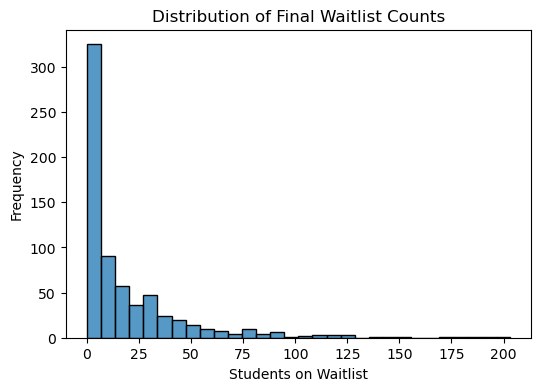

In [16]:
    # 5 (Optional) SUMMARY STATISTICS

    print("\n--- Summary Statistics (Cleaned) ---")
    display(df[['fill_rate_0to12h', 'final_waitlist_count']].describe())
    
    # Quick visual check of the most important metric
    plt.figure(figsize=(6, 4))
    sns.histplot(df['final_waitlist_count'], bins=30, kde=False)
    plt.title('Distribution of Final Waitlist Counts')
    plt.xlabel('Students on Waitlist')
    plt.ylabel('Frequency')
    plt.show()

## Results

### Exploratory Data Analysis


In [17]:
df = pd.read_csv("data/02-processed/course_enrollment_clean.csv")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Distribution of Enrollment Speed and Waitlist Variables

This section examines the distribution of enrollment speed and final demand indicators using histograms.
It addresses the question: “How are enrollment speeds and waitlist outcomes distributed across courses?”

We first examine the distributions of enrollment speed variables and final waitlist ratios using histograms to understand their overall patterns.

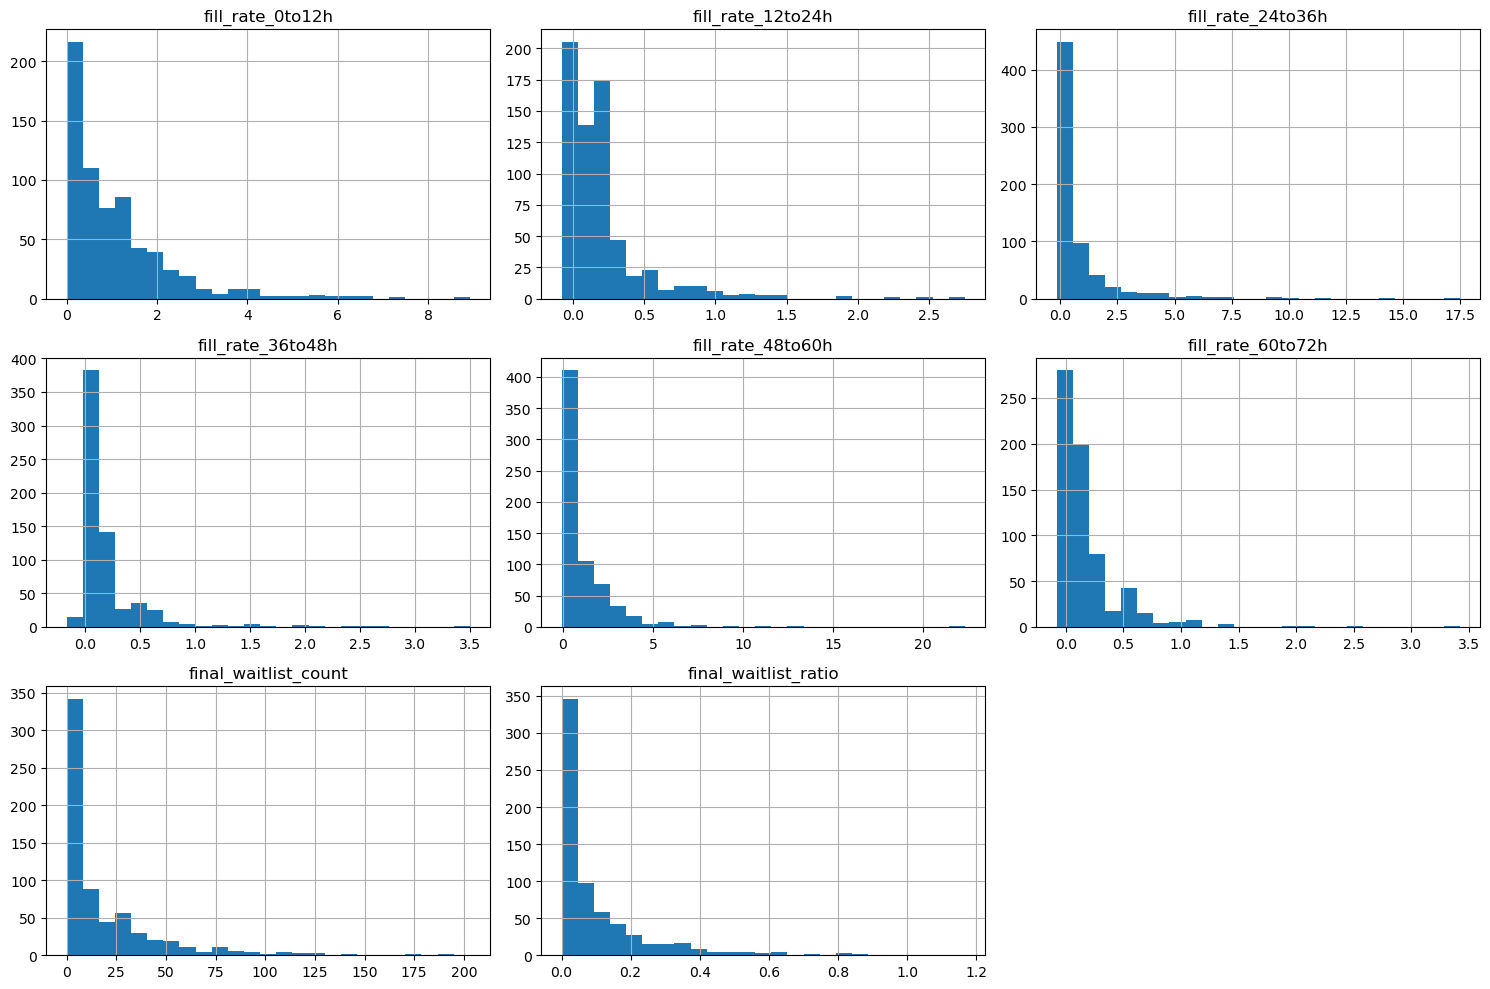

In [18]:
# Plot histograms of fill_rates, final_waitlist_count, final_waitlist_ratio
cols = [
    "fill_rate_0to12h",
    "fill_rate_12to24h",
    "fill_rate_24to36h",
    "fill_rate_36to48h",
    "fill_rate_48to60h",
    "fill_rate_60to72h",
    "final_waitlist_count",
    "final_waitlist_ratio"
]

df[cols].hist(bins=25, figsize=(15,10))
plt.tight_layout()
plt.show()


#### Analysis
Most enrollment speed variables show strong right-skewness, with many courses experiencing small enrollment changes during each 12-hour window and a smaller number showing rapid early enrollment.

Similarly, the distribution of `final_waitlist_count` is heavily right-skewed. 
Most courses have small waitlists, while a few courses accumulate a large number 
of students, suggesting highly uneven demand across courses.

The `final_waitlist_ratio` variable is also concentrated near zero, indicating 
that for most courses the waitlist size is small relative to total seats.


#### Correlation of Early Enrollment Speed with Final Waitlist Ratio

This section answers the question: “Does early demand visually relate to the final waitlist?” 
Investigating the presence of a visual relationship between the early enrollment demand and the final waitlist is significant because it can reveal the presence of predictive information in the early enrollments regarding the final pressure in the courses.


In [19]:
# Select only the early fill rate variables (0–72 hours) and the final waitlist ratio (our outcome variable)

early_demand_df = df[[
    "fill_rate_0to12h",
    "fill_rate_12to24h",
    "fill_rate_24to36h",
    "fill_rate_36to48h",
    "fill_rate_48to60h",
    "fill_rate_60to72h",
    "fill_rate_0to72h",
    "final_waitlist_ratio"
]]


# Drop missing values to ensure accurate correlation calculation
early_demand_df = early_demand_df.dropna()

early_demand_df.head()


,fill_rate_0to12h,fill_rate_12to24h,fill_rate_24to36h,fill_rate_36to48h,fill_rate_48to60h,fill_rate_60to72h,fill_rate_0to72h,final_waitlist_ratio
0,0.50,0.58,1.00,0.25,0.83,0.17,3.33,0.013699
1,2.50,1.08,4.25,0.50,0.00,0.00,8.33,0.200000
2,0.08,0.17,0.33,0.08,0.25,0.00,0.91,0.000000
3,1.50,0.00,0.50,0.17,2.42,0.33,4.92,0.103118
4,0.83,0.17,0.25,0.00,1.25,0.17,2.67,0.008333


In [20]:
# Compute Pearson correlation matrix
# Pearson correlation measures the strength and direction of linear relationships between variables (-1 to +1)

correlation_matrix = early_demand_df.corr()

correlation_matrix


,fill_rate_0to12h,fill_rate_12to24h,fill_rate_24to36h,fill_rate_36to48h,fill_rate_48to60h,fill_rate_60to72h,fill_rate_0to72h,final_waitlist_ratio
fill_rate_0to12h,1.000000,0.585562,0.509581,0.422625,0.563649,0.402683,0.768228,0.221723
fill_rate_12to24h,0.585562,1.000000,0.669874,0.538576,0.606460,0.359656,0.769958,0.315915
fill_rate_24to36h,0.509581,0.669874,1.000000,0.823038,0.582730,0.127634,0.841751,0.183588
fill_rate_36to48h,0.422625,0.538576,0.823038,1.000000,0.452263,0.135428,0.710123,0.183749
fill_rate_48to60h,0.563649,0.606460,0.582730,0.452263,1.000000,0.671447,0.882462,0.156924
fill_rate_60to72h,0.402683,0.359656,0.127634,0.135428,0.671447,1.000000,0.525716,0.079600
fill_rate_0to72h,0.768228,0.769958,0.841751,0.710123,0.882462,0.525716,1.000000,0.227534
final_waitlist_ratio,0.221723,0.315915,0.183588,0.183749,0.156924,0.079600,0.227534,1.000000


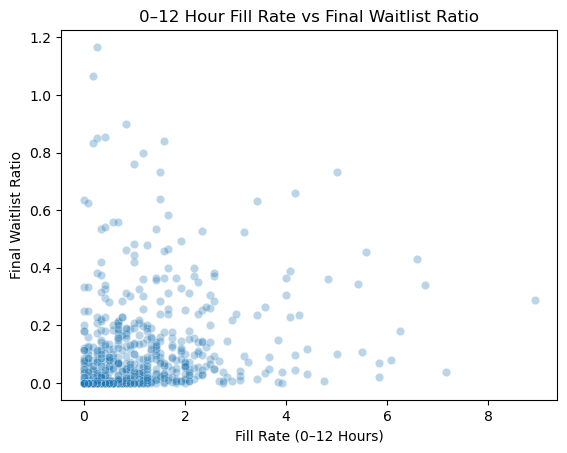

In [21]:
# Scatterplot showing relationship between first 12-hour fill rate
# and final waitlist ratio

sns.scatterplot(
    x="fill_rate_0to12h",
    y="final_waitlist_ratio",
    data=early_demand_df,
    alpha=0.3
)

plt.title("0–12 Hour Fill Rate vs Final Waitlist Ratio")
plt.xlabel("Fill Rate (0–12 Hours)")
plt.ylabel("Final Waitlist Ratio")
plt.show()


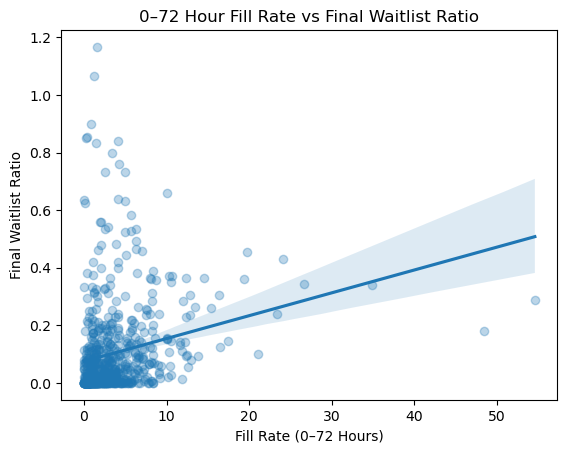

In [22]:
# Scatterplot showing relationship between cumulative 0–72 hour fill rate
# and final waitlist ratio

sns.regplot(
    x="fill_rate_0to72h",
    y="final_waitlist_ratio",
    data=early_demand_df,
    scatter_kws={"alpha": 0.3}
)

plt.title("0–72 Hour Fill Rate vs Final Waitlist Ratio")
plt.xlabel("Fill Rate (0–72 Hours)")
plt.ylabel("Final Waitlist Ratio")
plt.show()


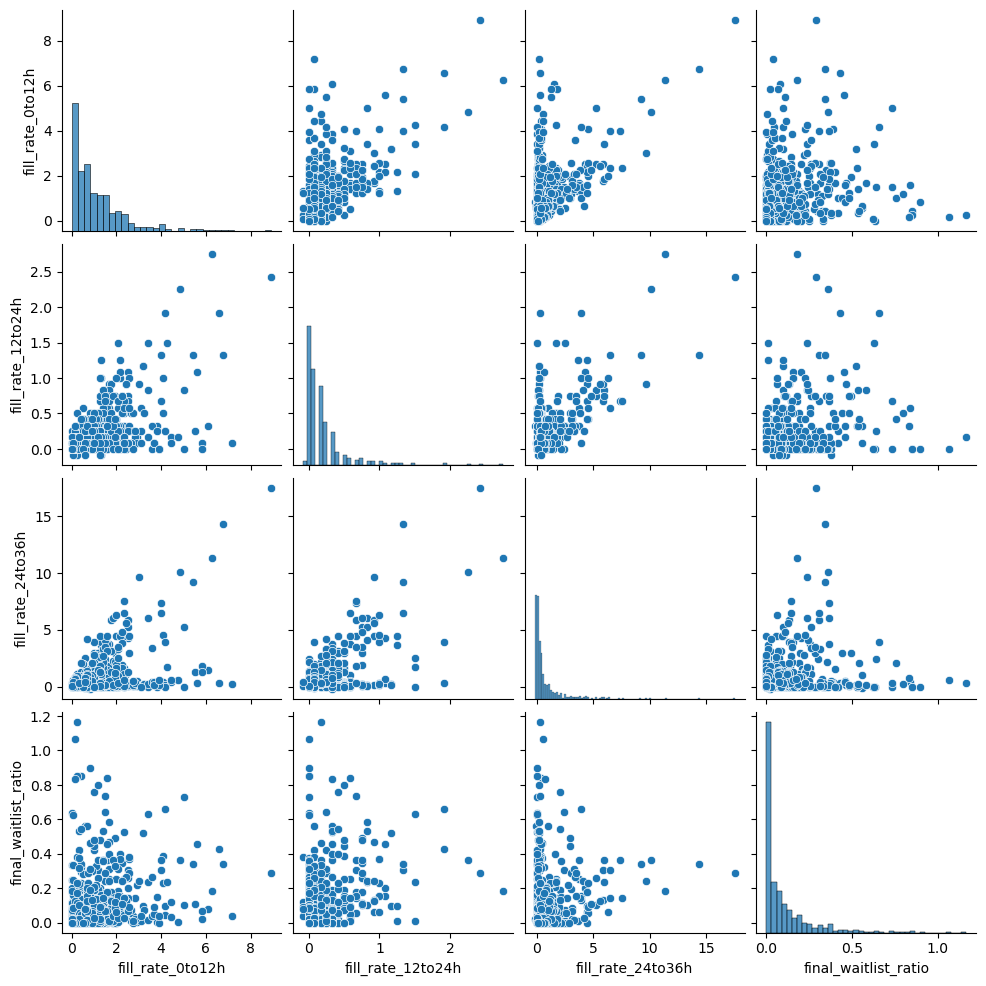

In [23]:
# Compare multiple time windows using pairplot
sns.pairplot(
    early_demand_df[[
        "fill_rate_0to12h",
        "fill_rate_12to24h",
        "fill_rate_24to36h",
        "final_waitlist_ratio"
    ]]
)

plt.show()


### Analysis
The results suggest a positive but small relationship between enrollment speed during the initial period and final waitlist ratio. The highest correlation is observed during the 12-24 hour window (r = 0.316), implying that enrollment activity during this window is most related to final waitlist ratio. The correlation is lower during the 0-12 hour window (r = 0.222) and steadily declines after 24 hours, eventually reaching negligible values during the 60-72 hour window (r = 0.080).

This trend is also confirmed in the scatterplots and pairplot visualizations. If we look at the trend, we can see a slight increase in the trend from early fill rates to the final waitlist ratio. At the same time, we can also see significant variability in the trend. This shows us that while there is some predictive quality in early fill rates, they are not a significant factor in determining waitlists. Large amounts of dispersion are observed within all time windows of the pairplots, implying that early enrollment speed plays a small part in the overall determination of the size of the waitlists. The distribution of the final waitlist ratio is heavily right-skewed, implying that the vast majority of courses have relatively small waitlists, with a few courses experiencing extremely large waitlists.

Overall, we can see that early demand is positively correlated to the final waitlist ratio, but the strength of this correlation is relatively weak to moderate.


### How total seats relates to final waitlist count or ratio

One factor that may influence waitlist outcomes is the overall capacity of a course. Larger classes can accommodate more students, while smaller classes may reach capacity more quickly, potentially generating different waitlist dynamics. To examine this, we ask: how does the total number of seats in a course relate to its final waitlist size or waitlist ratio? Understanding this relationship is important for our broader research question because it helps determine whether observed waitlist patterns reflect true demand or are partially driven by differences in course capacity. If class size systematically affects waitlist outcomes, it should be considered when interpreting or modeling enrollment demand.

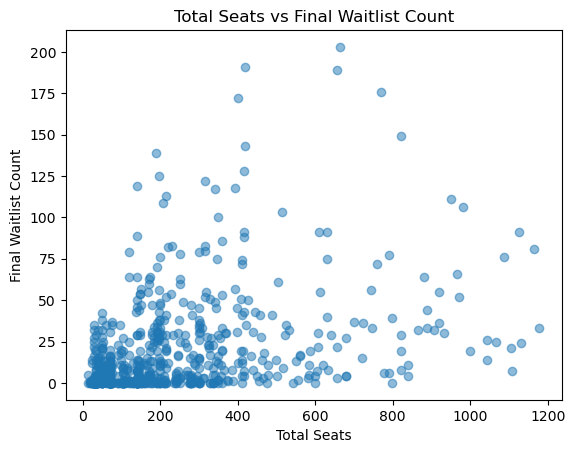

In [24]:
# Create a scatter plot to visualize the relationship between course capacity
# (total seats) and the final waitlist count for each course offering.

from pathlib import Path

plt.scatter(df["total_seats"], df["final_waitlist_count"], alpha=0.5)
plt.xlabel("Total Seats")
plt.ylabel("Final Waitlist Count")
plt.title("Total Seats vs Final Waitlist Count")
plt.show()

This plot suggests that absolute waitlist counts are influenced by class size.
Large classes can physically accumulate more waitlisted students.

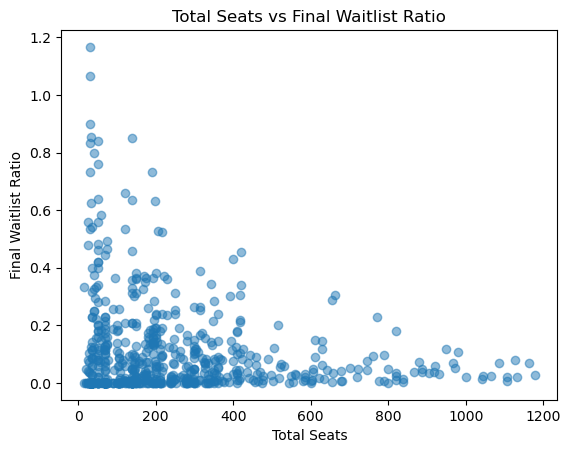

In [25]:
# Visualize how course capacity relates to relative waitlist size
# (waitlist normalized by course seats).
plt.scatter(df["total_seats"], df["final_waitlist_ratio"], alpha=0.5)
plt.xlabel("Total Seats")
plt.ylabel("Final Waitlist Ratio")
plt.title("Total Seats vs Final Waitlist Ratio")
plt.show()


You can see a clear downward shape. Smaller classes tend to have higher waitlist ratios. Large classes rarely have large ratios. Total seats strongly affect the waitlist ratio. If you model waitlist counts directly.

We additionally examined the relationship between course capacity and waitlist outcomes to assess whether class size systematically influenced demand patterns. Exploratory analysis compared both absolute waitlist counts and waitlist ratios across courses of varying sizes, revealing differences between small and large classes that motivated controlling for total seats in subsequent analyses.


### Distribution of Final Waitlist Ratios Across Courses

This section answers the question: “Do some courses behave fundamentally differently?”

Investigating the differences in final waitlist ratios across individual courses is significant because it can reveal whether enrollment pressure is a uniform trend across the department or highly course-specific. Understanding this variance helps determine if the specific course identity (like COGS 1 vs. COGS 108) is a necessary and strong predictive feature for anticipating future waitlist sizes.


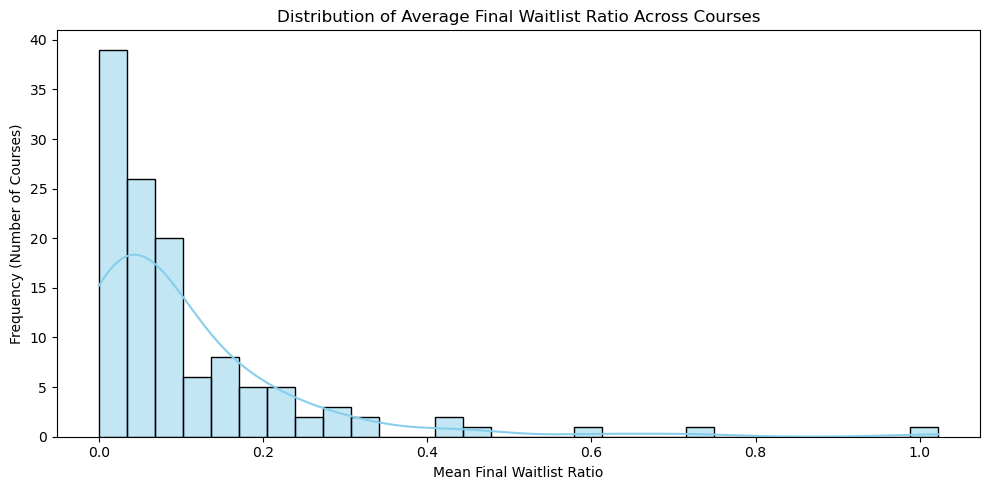

In [26]:
# 1. Generating a histogram showing the distribution of the average final waitlist ratio across all courses.
# Group by course to find the mean waitlist ratio and the number of times it was offered

course_stats = df.groupby('subj_course_id')['final_waitlist_ratio'].agg(['mean', 'count']).reset_index()

# Filter for courses with at least 3 occurrences to avoid outliers from classes only offered once or twice

course_stats = course_stats[course_stats['count'] >= 3]

# Plot the distribution of the mean final waitlist ratios

plt.figure(figsize=(10, 5))
sns.histplot(course_stats['mean'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Average Final Waitlist Ratio Across Courses')
plt.xlabel('Mean Final Waitlist Ratio')
plt.ylabel('Frequency (Number of Courses)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_864/537627696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_15, x='final_waitlist_ratio', y='subj_course_id', order=top_15_mean, palette='Set2')


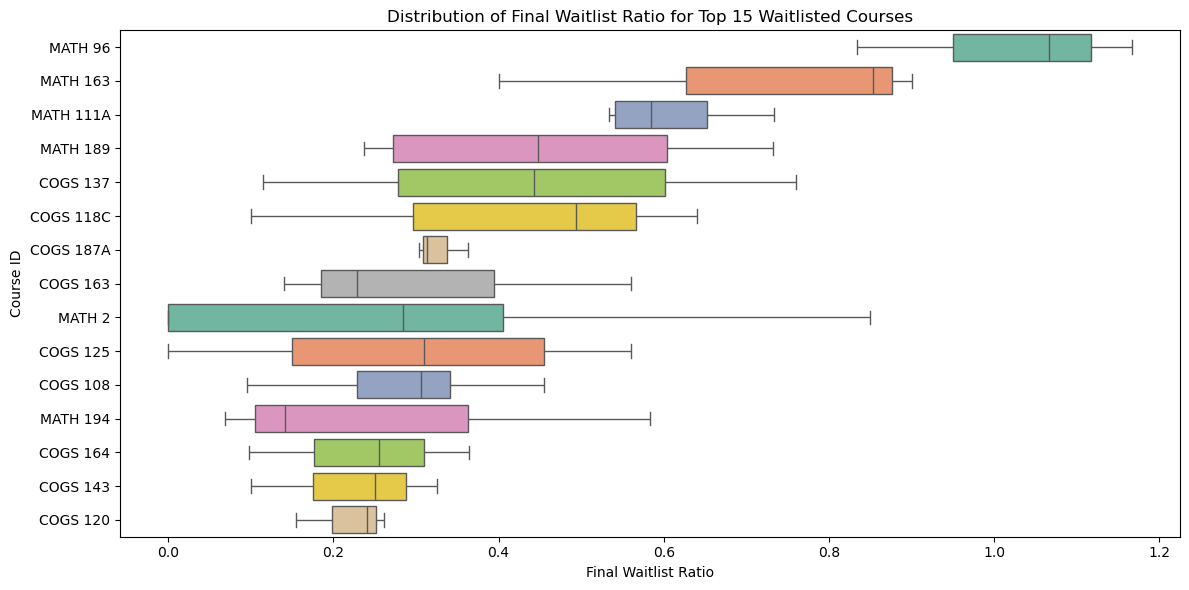

In [27]:
# 2. Generating a boxplot showing the distribution of the average waitlist ratios for the top 15 courses with highest waitlists.
#
#
# Filter for courses with at least 3 occurrences to ensure we have enough data per course

course_counts = df['subj_course_id'].value_counts()
valid_courses = course_counts[course_counts >= 3].index
df_valid = df[df['subj_course_id'].isin(valid_courses)].copy()

# Find the top 15 courses with the highest average final waitlist ratio

top_15_mean = df_valid.groupby('subj_course_id')['final_waitlist_ratio'].mean().sort_values(ascending=False).head(15).index
df_top_15 = df_valid[df_valid['subj_course_id'].isin(top_15_mean)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_15, x='final_waitlist_ratio', y='subj_course_id', order=top_15_mean, palette='Set2')
plt.title('Distribution of Final Waitlist Ratio for Top 15 Waitlisted Courses')
plt.xlabel('Final Waitlist Ratio')
plt.ylabel('Course ID')
plt.tight_layout()
plt.show()

### Analysis

The results suggest that courses do behave fundamentally differently from one another, and waitlist ratios are far from uniform across all classes.

This trend is clearly confirmed in the distribution visualizations. If we look at the histogram of the average final waitlist ratios, the distribution is heavily right-skewed. This implies that the vast majority of courses have an average waitlist ratio close to zero, meaning they rarely fill up or only accumulate very small waitlists. However, a small "tail" of specific courses consistently experiences extremely large waitlists, behaving fundamentally differently from the majority.

This variability is further highlighted in the boxplot of the top 15 waitlisted courses. We can see that even among the highest-demand classes, the median waitlist ratio and the spread of the data are distinct to each specific course. Some courses have tight, consistently high waitlist ratios, while others show much wider dispersion across different quarters.

Overall, we can see that enrollment rates and waitlist ratios differ significantly from course to course, indicating that a course's specific identity is a major determining factor in its final waitlist size.


## Course Enrollment Consistency Across Quarters and Years

The question we are trying to explore in this section is: **"Do enrollment fill rates vary more between quarters (Fall vs Winter vs Spring) or within the same quarter across years?"** 

We investigate whether enrollment behavior for a given course is more consistent within the same quarter across different years or across all quarters combined. Specifically, we examine whether the variability in early enrollment metrics is greater overall or within individual quarters.

Understanding this distinction is important for prediction. If enrollment behavior is more consistent within the same quarter across years, then quarter-specific historical data may provide stronger signals when forecasting demand. For example, when predicting enrollment for a course in Winter 2025, it may be more informative to look at previous Winter offerings of that course rather than considering all past offerings equally.

In [28]:
import warnings
warnings.filterwarnings("ignore")


In [29]:
# Extract the season(quarter name) ex: 'Fa' from 'Fa22'
df["season"] = df["quarter"].str[:2]

### Filtering

To explore this question, we first identify courses that are offered consistently across quarters and years. Comparing variability across quarters requires courses with stable offering patterns, so we focus on courses that follow consistent schedules across the dataset.

First, we identify courses that are offered in all three quarters (Fall, Winter, and Spring) each year. These courses allow us to directly compare enrollment patterns across quarters.

In [30]:
"""
Check whether a course appears exactly three times in each quarter
(Fall, Winter, Spring) in the dataset.

"""
def is_all_three_quarters(course_df):
    
    return (course_df["season"].nunique() == 3 and course_df["season"].value_counts()['Fa'] == 3 
            and course_df["season"].value_counts()['Wi'] == 3 
            and course_df["season"].value_counts()['Sp'] == 3 )

In [31]:
# Creates a dataset that only contains courses that appear exactly three times in each quarter
courses_all_three = df.groupby("subj_course_id").filter(is_all_three_quarters)

In [32]:
print("Number of 'all three quarters' = ", courses_all_three["subj_course_id"].nunique())

Number of 'all three quarters' =  22


After applying this filter, we obtain a subset of 22 courses that maintain consistent quarterly offerings. This subset allows us to fairly compare enrollment variability within quarters and across quarters without being affected by inconsistent scheduling patterns.

### Stats

Next, we compute several measures of variability in early enrollment behavior for each course.

We calculate:
**Overall standard deviation**, which measures how much early enrollment varies across all offerings of the course.

**Within-quarter standard deviation**, which measures how much enrollment varies within the same quarter across different years.

**Seasonal mean standard deviation**, which captures how much the average enrollment differs between quarters.

These measures allow us to compare whether variability is primarily driven by differences across quarters or fluctuations within the same quarter across years.

In [33]:
"""
Compute variability statistics for early enrollment behavior of a course.

"""
def variability_stats(course_df):

    overall_std = course_df["fill_rate_0to72h"].std()

    season_std = course_df.groupby("season")["fill_rate_0to72h"].std()

    season_means = course_df.groupby("season")["fill_rate_0to72h"].mean()
    seasonal_mean_std = season_means.std()

    return pd.Series({
        "overall_std": overall_std,
        "within_fall_std": season_std.get("Fa"),
        "within_winter_std": season_std.get("Wi"),
        "within_spring_std": season_std.get("Sp"),
        "seasonal_mean_std": seasonal_mean_std
    })

In [34]:
# Creating a table of variability statistics for all courses that appear exactly three times in each quarter
table1_stats = courses_all_three.groupby("subj_course_id").apply(variability_stats)

The resulting table shows the variability metrics for each course. By comparing the overall standard deviation with the within-quarter standard deviations, we can assess whether enrollment behavior tends to fluctuate more across different quarters or across years within the same quarter.

To better understand the overall trends, we summarize these statistics across all courses in the subset.

In [35]:
# Summary statistics of table 1. We are mainly interested in mean and median
table1_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,22.000000,22.000000,22.000000,22.000000,22.000000
mean,2.768267,0.627749,2.116091,0.953384,2.762028
std,3.086284,0.474284,2.261388,1.026041,3.356066
min,0.822741,0.043589,0.407226,0.040415,0.688979
25%,1.659944,0.343887,0.864756,0.483764,1.472722
50%,1.987029,0.572554,1.486019,0.726699,1.993135
75%,2.926511,0.881751,2.109536,1.063428,2.945012
max,15.969332,2.152239,10.064333,5.134034,17.202684


The summary statistics show that variability in early fill rates is larger across all offerings of a course than within individual quarters. Across the 22 courses offered every quarter, the average overall standard deviation is 2.77, indicating moderate variation when all offerings are considered together.

In contrast, variability within individual quarters is much smaller. The average within-quarter standard deviation is 0.63 for Fall and 0.95 for Spring, suggesting that enrollment behavior is relatively stable within the same quarter across years. The seasonal mean standard deviation (2.76) is nearly identical to the overall value, indicating that much of the variation is driven by differences between quarters rather than changes within the same quarter over time.

Because a few courses show unusually high variability, the median provides a more typical estimate. The median overall standard deviation is 1.99, while the within-quarter medians (0.57 for Fall, 1.49 for Winter, and 0.73 for Spring) are consistently lower. Overall, these results suggest that enrollment patterns tend to remain stable within a given quarter across years but differ more noticeably between Fall, Winter, and Spring offerings.

#### Second subset

However, not all courses are offered in all three quarters each year. To ensure that our findings are not limited to this specific subset, we repeat the analysis using courses that are offered consistently in two quarters each year. Examples include courses offered every Fall and Winter or every Winter and Spring.

These steps produce additional subsets of courses with stable two-quarter offering schedules. These subsets allow us to perform the same variability analysis while including more courses in the study.

In [36]:
"""
Check whether a course appears in exactly two quarters every year.
"""
def is_two_quarters(course_df):
    return course_df["season"].nunique() == 2

In [37]:
# Create a new dataframe that only contain courses that appear in exactly two quarters every year
courses_two = df.groupby("subj_course_id").filter(is_two_quarters)

In [38]:
"""
Check whether a course appears once in each Fall and Winter quarter
across the years, and in no other quarters.
"""
def is_fall_winter(course_df):
    counts = course_df["quarter"].value_counts()
    required = ["Fa22", "Wi23", "Fa23", "Wi24", "Fa24", "Wi25"]
    has_all_required_once = all(counts.get(q, 0) == 1 for q in required)
    no_other_quarters = set(counts.index).issubset(set(required))

    return has_all_required_once and no_other_quarters

In [39]:
"""
Check whether a course appears once in each Winter and Spring quarter
across the specified years, and in no other quarters.

"""
def is_winter_spring(course_df):
    counts = course_df["quarter"].value_counts()
    required = ["Wi23", "Sp23", "Wi24", "Sp24", "Wi25", "Sp25"]
    return all(counts.get(q, 0) == 1 for q in required) and set(counts.index).issubset(set(required))

"""
Check whether a course appears once in each Fall and Spring quarter
across the specified years, and in no other quarters.
"""
def is_fall_spring(course_df):
    counts = course_df["quarter"].value_counts()
    required = ["Fa22", "Sp23", "Fa23", "Sp24", "Fa24", "Sp25"]
    return all(counts.get(q, 0) == 1 for q in required) and set(counts.index).issubset(set(required))

In [40]:
# Split the two-season courses into Fall-Winter, Winter-Spring, and Fall-Spring subsets.
fw = courses_two.groupby("subj_course_id").filter(is_fall_winter)
ws = courses_two.groupby("subj_course_id").filter(is_winter_spring)
fs = courses_two.groupby("subj_course_id").filter(is_fall_spring)

In [41]:
# Compute variability statistics for each course within each two-quarter subset.
fw_stats = fw.groupby("subj_course_id").apply(variability_stats)
ws_stats = ws.groupby("subj_course_id").apply(variability_stats)
fs_stats = fs.groupby("subj_course_id").apply(variability_stats)

In [42]:
fw_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,4.000000,4.000000,4.000000,0.0,4.000000
mean,1.520444,0.421181,0.810974,NaN,1.787212
std,0.793832,0.289133,0.339454,NaN,1.026561
min,0.657736,0.206640,0.529371,NaN,0.667037
25%,1.013816,0.253092,0.547425,NaN,1.094837
50%,1.475698,0.317250,0.734279,NaN,1.767767
75%,1.982326,0.485339,0.997827,NaN,2.460142
max,2.472642,0.843584,1.245967,NaN,2.946278


For courses offered in Fall and Winter each year, the average overall variability in early fill rates is 1.52, while the within-quarter variability is smaller, with mean standard deviations of 0.42 for Fall and 0.81 for Winter.

Examining the medians provides a similar picture. The median overall standard deviation is 1.48, compared to 0.32 for Fall and 0.73 for Winter. This again indicates that for a typical course in this subset, enrollment behavior tends to be relatively consistent within the same quarter across years.

In [43]:
ws_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,8.000000,0.0,8.000000,8.000000,8.000000
mean,3.186369,NaN,2.594556,0.987091,3.116868
std,2.417748,NaN,3.143306,1.095609,2.172627
min,0.458636,NaN,0.254231,0.046188,0.551543
25%,1.358201,NaN,0.691174,0.285751,1.687039
50%,2.814286,NaN,2.018613,0.367472,3.220871
75%,4.101350,NaN,2.489185,1.607849,3.575603
max,7.174300,NaN,9.945780,3.057401,7.653252


For courses offered in Winter and Spring each year, the average overall variability is 3.19, with within-quarter variability of 2.59 for Winter and 0.99 for Spring.

Looking at the medians provides additional insight. The median overall standard deviation is 2.81, while the median within-quarter values are 2.02 for Winter and 0.37 for Spring. These results again suggest that early enrollment behavior tends to be more stable within a given quarter across years than across all offerings combined.

In [44]:
fs_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,2.000000,2.000000,0.0,2.000000,2.000000
mean,1.180844,0.648998,NaN,1.542011,0.667037
std,0.459291,0.079609,NaN,0.679244,0.256667
min,0.856076,0.592706,NaN,1.061712,0.485547
25%,1.018460,0.620852,NaN,1.301862,0.576292
50%,1.180844,0.648998,NaN,1.542011,0.667037
75%,1.343228,0.677144,NaN,1.782160,0.757783
max,1.505612,0.705290,NaN,2.022309,0.848528


For courses offered in Fall and Spring each year, the average overall variability is 1.18, with mean within-quarter standard deviations of 0.65 for Fall and 1.54 for Spring.

Because this subset contains only two courses, the median values are identical to the means for the overall variability measure. The median overall standard deviation is 1.18, compared to 0.65 for Fall and 1.54 for Spring.

The results for these courses show patterns similar to those observed in the three-quarter subset. In many cases, variability across quarters remains larger than variability within the same quarter across years.

It is important to note that this analysis was conducted on a subset of courses with consistent offering patterns across years. Specifically, we examined 22 courses offered in all three quarters each year and 14 courses offered consistently in two quarters per year, resulting in a total of 36 courses out of the 145 unique courses in the dataset.

This filtering was necessary in order to meaningfully compare variability within specific quarters across years. Courses with irregular offering schedules do not provide sufficient observations within each quarter to support this type of comparison.

As a result, the findings in this section should be interpreted as evidence of general patterns among regularly offered courses, rather than as conclusions that necessarily apply to every course in the dataset. Nonetheless, these courses represent those with the most consistent historical data, making them particularly informative when examining enrollment patterns over time.

### Visual exploration: Some examples

While summary statistics provide useful insights, visualizing individual courses can help illustrate these patterns more clearly. To do this, we plot early enrollment metrics for several popular example courses across different quarters and years.

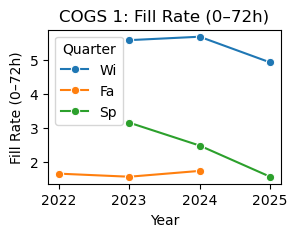

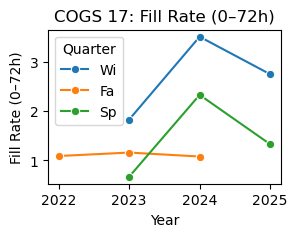

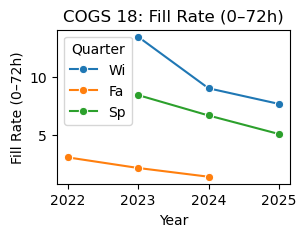

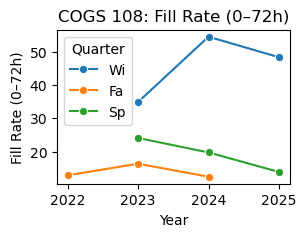

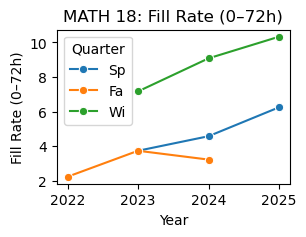

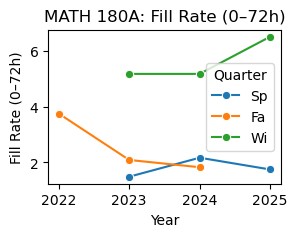

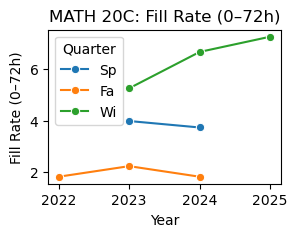

In [45]:
# Plot enrollment trends for selected courses to visualize how early fill rates
# (0–72 hours after registration opens) change across years and seasons.
for course in ["COGS 1", "COGS 17", "COGS 18", "COGS 108","MATH 18","MATH 180A","MATH 20C"]:
    df_course = df[df["subj_course_id"] == course].copy()
    # extract year and season
    df_course["season"] = df_course["quarter"].str[:2]
    df_course["year"] = 2000 + df_course["quarter"].str[2:].astype(int)
    plt.figure(figsize=(3,2))

    sns.lineplot(
        data=df_course,
        x="year",
        y="fill_rate_0to72h",
        hue="season",
        marker="o"
    )
    plt.title(f"{course}: Fill Rate (0–72h)")
    plt.xlabel("Year")
    plt.ylabel("Fill Rate (0–72h)")
    plt.legend(title="Quarter")

    plt.show()

These plots highlight how enrollment patterns vary between quarters for the same course while remaining relatively stable within the same quarter across different years.

#### Conclusion
Overall, the results across all subsets suggest that early enrollment behavior tends to be relatively consistent within the same quarter across different years, while variability between different quarters of the same course can be larger.

This pattern indicates that quarter-specific historical enrollment data may contain useful predictive signals. When forecasting enrollment demand for a course in a particular quarter, examining previous offerings of that course in the same quarter across past years may provide more relevant information than treating all past offerings equally.

These findings motivate the use of quarter-aware historical features when modeling the relationship between early enrollment metrics and final waitlist demand.

### Linear Regression Model Analysis

To examine how early enrollment behavior relates to final course demand, we first estimate a linear regression model predicting the final waitlist ratio using early fill rates, course capacity, and seasonal indicators.

In [46]:
# Statmodels
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

##### Log Transformation of fill rates

Many of the fill rate variables are **highly right skewed** because most courses fill slowly while a small number fill very quickly. 

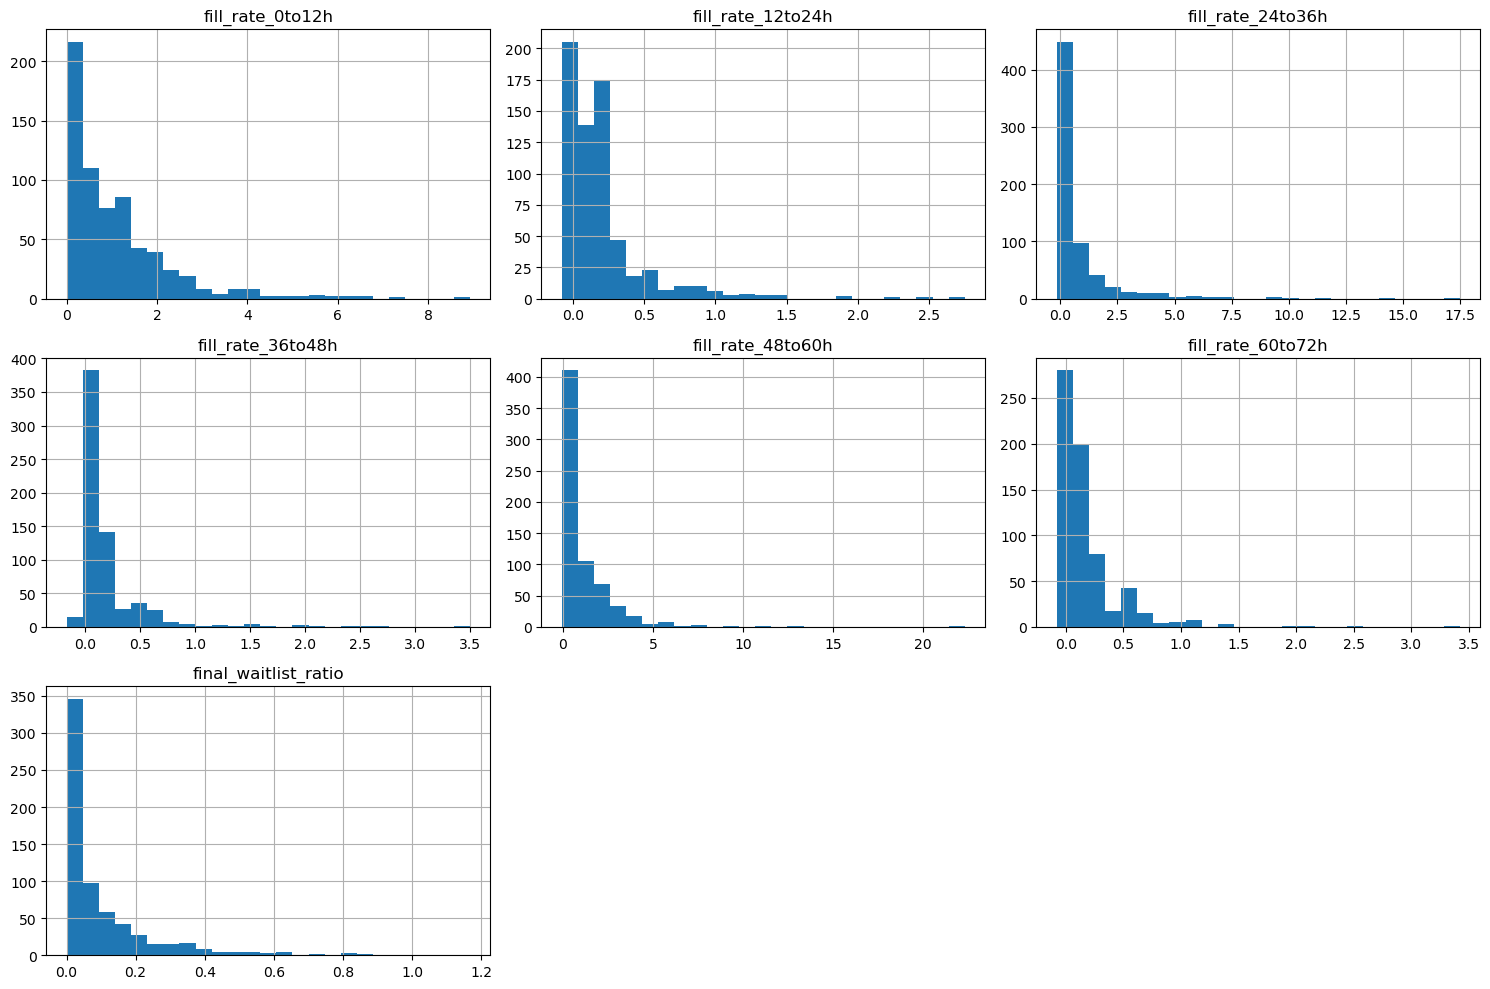

In [47]:
# Plot histograms of fill_rates and final_waitlist_ratio
df.head()
df.columns
cols = [
    "fill_rate_0to12h",
    "fill_rate_12to24h",
    "fill_rate_24to36h",
    "fill_rate_36to48h",
    "fill_rate_48to60h",
    "fill_rate_60to72h",
    "final_waitlist_ratio"
]

df[cols].hist(bins=25, figsize=(15,10))
plt.tight_layout()
plt.show()


To reduce this skewness and improve model stability, we apply a **log transformation to each fill rate variable**. The transformation compresses large values and helps approximate a more normal distribution, which improves the behavior of linear regression models.

In [48]:
# Create new log_fill_rate columns that perform a log transform on the fill rate columns
df["log_fill_rate_0to12h"]  = np.log10(df["fill_rate_0to12h"]  + 1)
df["log_fill_rate_12to24h"] = np.log10(df["fill_rate_12to24h"] + 1)
df["log_fill_rate_24to36h"] = np.log10(df["fill_rate_24to36h"] + 1)
df["log_fill_rate_36to48h"] = np.log10(df["fill_rate_36to48h"] + 1)
df["log_fill_rate_48to60h"] = np.log10(df["fill_rate_48to60h"] + 1)
df["log_fill_rate_60to72h"] = np.log10(df["fill_rate_60to72h"] + 1)
df["log_fill_rate_0to72h"] = np.log10(df["fill_rate_0to72h"] + 1)

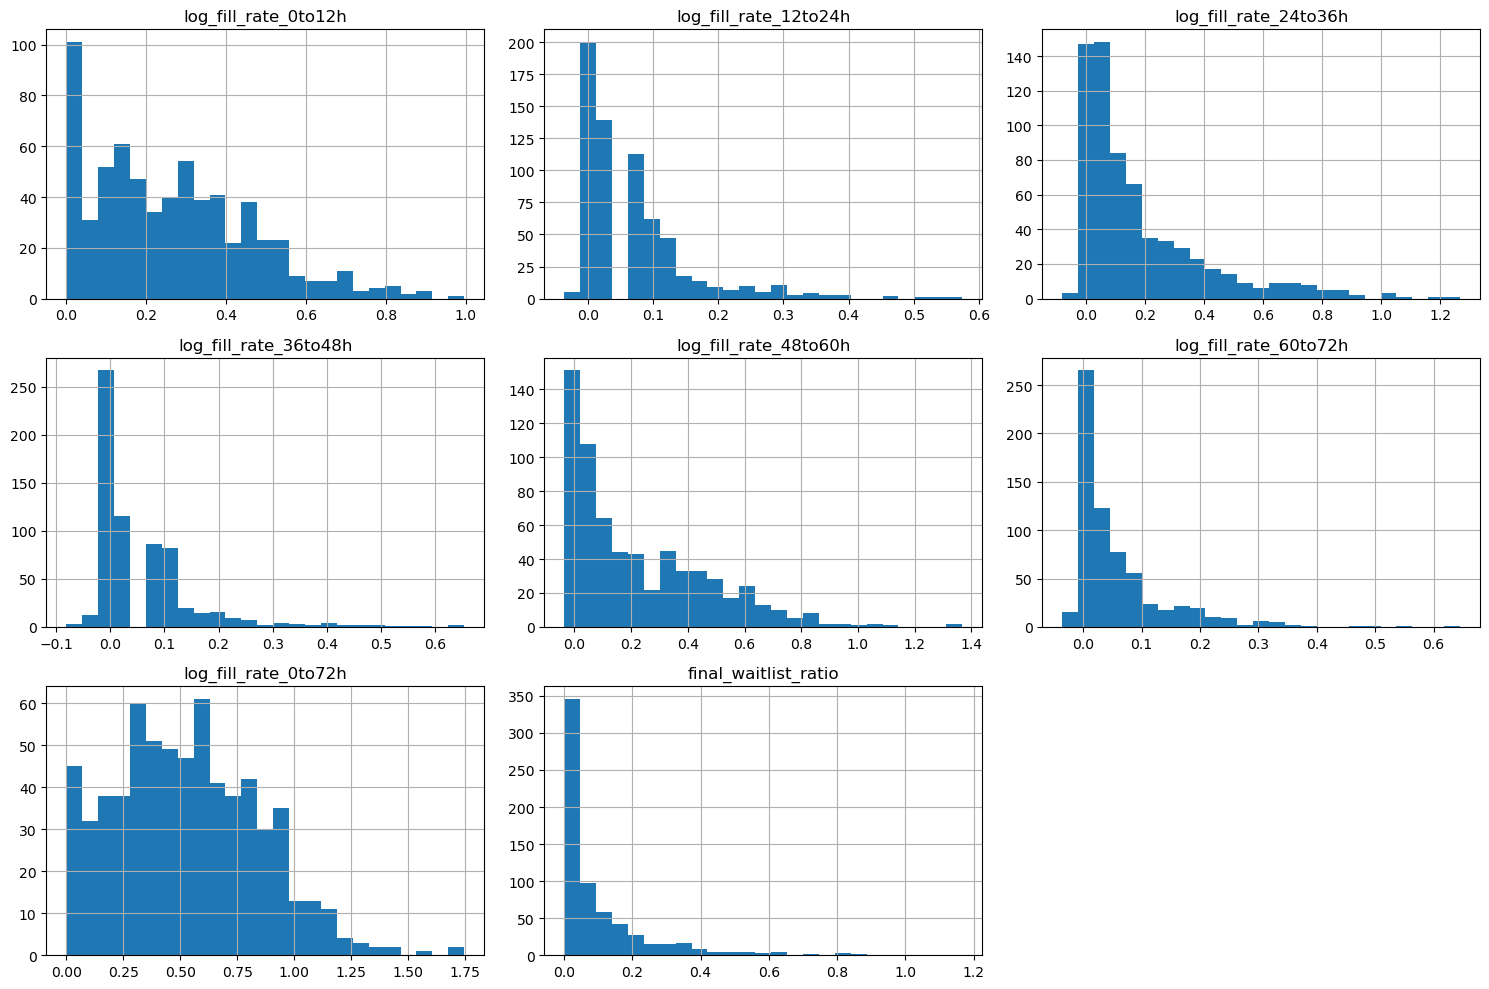

In [49]:
#Plot histograms of the newly created log_fill_rate_column
df.head()
df.columns
cols = [
    "log_fill_rate_0to12h",
    "log_fill_rate_12to24h",
    "log_fill_rate_24to36h",
    "log_fill_rate_36to48h",
    "log_fill_rate_48to60h",
    "log_fill_rate_60to72h",
    "log_fill_rate_0to72h",
    "final_waitlist_ratio"
]

df[cols].hist(bins=25, figsize=(15,10))
plt.tight_layout()
plt.show()

In [50]:
# Extract the season(quarter name) ex: 'Fa' from 'Fa22'
df["season"] = df["quarter"].str[:2]


The outcome variable for this analysis is final_waitlist_ratio, which measures the proportion of students on the waitlist relative to course capacity at the end of the enrollment period.

Using a ratio instead of raw waitlist counts allows us to compare courses of different sizes in a consistent way.

In [51]:
y = "final_waitlist_ratio"

We define a set of potential predictor variables that may influence final waitlist ratios. These include:

- log-transformed fill rates for multiple enrollment windows
- raw fill rates
- total number of course seats
- seasonal indicators

In [52]:
# List of all the potential independent variables
xvariables = [
    "log_fill_rate_0to12h",
    "log_fill_rate_12to24h",
    "log_fill_rate_24to36h",
    "log_fill_rate_36to48h",
    "log_fill_rate_48to60h",
    "log_fill_rate_60to72h",
    "log_fill_rate_0to72h",
    "fill_rate_0to12h",
    "fill_rate_12to24h",
    "fill_rate_24to36h",
    "fill_rate_36to48h",
    "fill_rate_48to60h",
    "fill_rate_60to72h",
    "fill_rate_0to72h",
    "total_seats",
    "C(season)",
]

#### Feed Forward Model Selection

To determine which variables best predict final waitlist ratios, we used a forward model selection approach. Starting with the strongest single predictor, we iteratively added additional variables that improved the model’s adjusted R² while remaining statistically significant.

This approach allows us to identify a set of predictors that meaningfully explain variation in waitlist ratios without unnecessarily increasing model complexity.

In [53]:
single_models = []

# Create and fit a linear model using a single variable x, for each x from our potential independent variable list
for x in xvariables:
    
    formula = f"{y} ~ {x}"
    model = smf.ols(formula, data=df).fit()
    
    single_models.append((x, model))

# Display each model's R-squared, Adj R-squared and p-value(s)
for x, model in single_models:
    
    print("\nModel:", f"{y} ~ {x}")
    print("R-squared:", model.rsquared)
    print("Adj R-squared:", model.rsquared_adj)
    
    if x == "C(season)":
        print("p-values:")
        print(model.pvalues.filter(like="C(season)"))
    else:
        print("p-value:", model.pvalues[x])
        
    print("-----------------------------")


Model: final_waitlist_ratio ~ log_fill_rate_0to12h
R-squared: 0.052604780918984906
Adj R-squared: 0.051160580889898055
p-value: 2.6538225183768685e-09
-----------------------------

Model: final_waitlist_ratio ~ log_fill_rate_12to24h
R-squared: 0.10051741874192699
Adj R-squared: 0.099146256270497
p-value: 7.872417203351345e-17
-----------------------------

Model: final_waitlist_ratio ~ log_fill_rate_24to36h
R-squared: 0.030119013404303896
Adj R-squared: 0.028640536290591045
p-value: 7.558227652342525e-06
-----------------------------

Model: final_waitlist_ratio ~ log_fill_rate_36to48h
R-squared: 0.03137250819368498
Adj R-squared: 0.02989594189519984
p-value: 4.853569309664063e-06
-----------------------------

Model: final_waitlist_ratio ~ log_fill_rate_48to60h
R-squared: 0.01494000176555832
Adj R-squared: 0.013438385914591233
p-value: 0.0016826276688159051
-----------------------------

Model: final_waitlist_ratio ~ log_fill_rate_60to72h
R-squared: 0.004047784069275084
Adj R-square

Among all candidate predictors, the log-transformed fill rate during the 12–24 hour registration window **(log_fill_rate_12to24h)** produced the highest R² value.

Because this variable provided the strongest single predictor of final waitlist ratios, it was selected as the starting point for the forward selection process.

In [54]:
best_single_x = "log_fill_rate_12to24h"

In [55]:
"""
Helper function for forward model selection. Evaluates candidate predictors during forward model selection.

Parameters
----------
xvariables : list
    List of candidate predictor variables that can be added to the model.
y : str
    Name of the dependent variable.
selected_vars : list
    Predictor variables currently included in the base model.

The function prints the adjusted R² and p-values for models formed
by adding each candidate variable to the base model.
"""

def make_display_models(xvariables, y, selected_vars):
    base_formula = f"{y} ~ " + " + ".join(selected_vars)
    base_model = smf.ols(base_formula, data=df).fit()
    
    print("Base model:", base_formula)
    print("Base adjusted R²:", base_model.rsquared_adj)
    print("-" * 50)
    
    models = []
    
    for xvar in xvariables:
        if xvar in selected_vars:
            continue
            
        new_formula = f"{y} ~ " + " + ".join(selected_vars + [xvar])
        model = smf.ols(new_formula, data=df).fit()
        models.append((xvar, model))
    
    for xvar, model in models:
        print("\nVariable added:", xvar)
        print("Adjusted R²:", model.rsquared_adj)
        
        if xvar == "C(season)":
            print("p-values for season terms:")
            print(model.pvalues.filter(like="C(season)"))
        else:
            print("p-value:", model.pvalues[xvar])

In the second step of forward selection, we tested **adding each remaining** variable to the model. 

In [56]:
selected_vars = ["log_fill_rate_12to24h"]
make_display_models(xvariables, y, selected_vars) #Step 2 with log_fill_rate_12to24h added

Base model: final_waitlist_ratio ~ log_fill_rate_12to24h
Base adjusted R²: 0.099146256270497
--------------------------------------------------

Variable added: log_fill_rate_0to12h
Adjusted R²: 0.10135815199457798
p-value: 0.10636149642659767

Variable added: log_fill_rate_24to36h
Adjusted R²: 0.09813427387010398
p-value: 0.6076244272717057

Variable added: log_fill_rate_36to48h
Adjusted R²: 0.09859755049851182
p-value: 0.4385996440571259

Variable added: log_fill_rate_48to60h
Adjusted R²: 0.09964447498067286
p-value: 0.2434425832359877

Variable added: log_fill_rate_60to72h
Adjusted R²: 0.09880161849842228
p-value: 0.387068272936382

Variable added: log_fill_rate_0to72h
Adjusted R²: 0.0984969338541275
p-value: 0.4679170683303576

Variable added: fill_rate_0to12h
Adjusted R²: 0.10028601018204575
p-value: 0.1764741761985744

Variable added: fill_rate_12to24h
Adjusted R²: 0.09848374981429531
p-value: 0.4719876095258928

Variable added: fill_rate_24to36h
Adjusted R²: 0.09833529130892682


The variable **total_seats** produced the largest improvement in adjusted R² and was highly statistically significant.

Third step...

In [57]:
selected_vars = ["log_fill_rate_12to24h", "total_seats"]

In [58]:
make_display_models(xvariables, y, selected_vars) # Step 3 with total_seats added into the equation

Base model: final_waitlist_ratio ~ log_fill_rate_12to24h + total_seats
Base adjusted R²: 0.12501112186526242
--------------------------------------------------

Variable added: log_fill_rate_0to12h
Adjusted R²: 0.17579010467634337
p-value: 2.4517883293200334e-10

Variable added: log_fill_rate_24to36h
Adjusted R²: 0.12397975750736268
p-value: 0.632538272470985

Variable added: log_fill_rate_36to48h
Adjusted R²: 0.12569576300778595
p-value: 0.2191377503973619

Variable added: log_fill_rate_48to60h
Adjusted R²: 0.12426740251606239
p-value: 0.5055583498379859

Variable added: log_fill_rate_60to72h
Adjusted R²: 0.12367465342000394
p-value: 0.9739033763555089

Variable added: log_fill_rate_0to72h
Adjusted R²: 0.13311793880291733
p-value: 0.007788755031563899

Variable added: fill_rate_0to12h
Adjusted R²: 0.16867688909594802
p-value: 4.366726189353135e-09

Variable added: fill_rate_12to24h
Adjusted R²: 0.1249845575559978
p-value: 0.3225365308260104

Variable added: fill_rate_24to36h
Adjusted 

The variable **log_fill_rate_0to12h** produced the largest improvement in adjusted R² and was highly statistically significant.

And the fourth...

In [59]:
selected_vars = ["log_fill_rate_12to24h", "total_seats", "log_fill_rate_0to12h"]

make_display_models(xvariables, y, selected_vars) # Step 4 with log_fill_rate_0to12h added

Base model: final_waitlist_ratio ~ log_fill_rate_12to24h + total_seats + log_fill_rate_0to12h
Base adjusted R²: 0.17579010467634337
--------------------------------------------------

Variable added: log_fill_rate_24to36h
Adjusted R²: 0.1806171459115219
p-value: 0.027950495154536275

Variable added: log_fill_rate_36to48h
Adjusted R²: 0.1748336691132073
p-value: 0.6229591834792363

Variable added: log_fill_rate_48to60h
Adjusted R²: 0.1890011113692165
p-value: 0.0006804380390236685

Variable added: log_fill_rate_60to72h
Adjusted R²: 0.1774461342317596
p-value: 0.12847671898885732

Variable added: log_fill_rate_0to72h
Adjusted R²: 0.1850921635804298
p-value: 0.00374296162757298

Variable added: fill_rate_0to12h
Adjusted R²: 0.17537789322705277
p-value: 0.4122795599407526

Variable added: fill_rate_12to24h
Adjusted R²: 0.1779748484961271
p-value: 0.09845720843940846

Variable added: fill_rate_24to36h
Adjusted R²: 0.17777039114855397
p-value: 0.10903960794507425

Variable added: fill_rate_3

The variable **season** produced the largest improvement in adjusted R² and was highly statistically significant.

And the fifth...

In [60]:
best_y = "final_waitlist_ratio"
selected_vars = ["log_fill_rate_12to24h", "total_seats", "log_fill_rate_0to12h", "C(season)"]
make_display_models(xvariables, y, selected_vars) # Step 5 with season variable added

Base model: final_waitlist_ratio ~ log_fill_rate_12to24h + total_seats + log_fill_rate_0to12h + C(season)
Base adjusted R²: 0.2308706454739038
--------------------------------------------------

Variable added: log_fill_rate_24to36h
Adjusted R²: 0.23593502364116958
p-value: 0.021375810107302533

Variable added: log_fill_rate_36to48h
Adjusted R²: 0.23031170720575944
p-value: 0.46833203469932516

Variable added: log_fill_rate_48to60h
Adjusted R²: 0.22999243729147645
p-value: 0.6127883930011377

Variable added: log_fill_rate_60to72h
Adjusted R²: 0.22968996338433745
p-value: 0.9795744523396747

Variable added: log_fill_rate_0to72h
Adjusted R²: 0.23111975469581747
p-value: 0.27149321513977304

Variable added: fill_rate_0to12h
Adjusted R²: 0.23109172569315628
p-value: 0.2762444529375506

Variable added: fill_rate_12to24h
Adjusted R²: 0.23263078954956107
p-value: 0.11465658817152363

Variable added: fill_rate_24to36h
Adjusted R²: 0.2320523404916437
p-value: 0.1574376138660557

Variable added:

The variable **log_fill_rate_24to36h** produced the largest improvement in adjusted R² and was highly statistically significant.

And the sixth...

In [61]:
best_y = "final_waitlist_ratio"
selected_vars = [
    "log_fill_rate_12to24h",
    "total_seats",
    "log_fill_rate_0to12h",
    "C(season)",
    "log_fill_rate_24to36h"
]

make_display_models(xvariables, y, selected_vars) # Step 6 with log_fill_rate_24to36h added

Base model: final_waitlist_ratio ~ log_fill_rate_12to24h + total_seats + log_fill_rate_0to12h + C(season) + log_fill_rate_24to36h
Base adjusted R²: 0.23593502364116958
--------------------------------------------------

Variable added: log_fill_rate_36to48h
Adjusted R²: 0.2360145029961731
p-value: 0.30184413349034145

Variable added: log_fill_rate_48to60h
Adjusted R²: 0.23476528405806862
p-value: 0.9443296964708773

Variable added: log_fill_rate_60to72h
Adjusted R²: 0.23477768242423935
p-value: 0.901240542305057

Variable added: log_fill_rate_0to72h
Adjusted R²: 0.23484181118242242
p-value: 0.7915808607804548

Variable added: fill_rate_0to12h
Adjusted R²: 0.2360895463140502
p-value: 0.2878116055004175

Variable added: fill_rate_12to24h
Adjusted R²: 0.23770494715612112
p-value: 0.1135036201976208

Variable added: fill_rate_24to36h
Adjusted R²: 0.23558316254786182
p-value: 0.40297546508635396

Variable added: fill_rate_36to48h
Adjusted R²: 0.23646519804161104
p-value: 0.22864042018218275

None satisfy p < 0.05. So no variable should be added.

Our forward model selection stops here

Our **final selected variables** are log_fill_rate_0to12h, log_fill_rate_12to24h, log_fill_rate_24to36h, total_seats, C(season). We shall use these as our final predictor variables in our model and display model statistics

In [62]:
# Create final model with selected final variables
final_model = smf.ols(
    "final_waitlist_ratio ~ log_fill_rate_0to12h + log_fill_rate_12to24h + log_fill_rate_24to36h + total_seats + C(season)",
    data=df
).fit()

# Display model summary
print(final_model.summary())

                             OLS Regression Results                             
Dep. Variable:     final_waitlist_ratio   R-squared:                       0.243
Model:                              OLS   Adj. R-squared:                  0.236
Method:                   Least Squares   F-statistic:                     34.81
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):           1.48e-36
Time:                          05:13:46   Log-Likelihood:                 358.34
No. Observations:                   658   AIC:                            -702.7
Df Residuals:                       651   BIC:                            -671.2
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept 

##### Results

To evaluate whether early enrollment activity predicts final waitlist sizes, we estimated a linear regression model with final waitlist ratio as the dependent variable. The predictors included early fill rates during the first three enrollment windows (0–12h, 12–24h, and 24–36h), total course seats, and season indicators.

The model explains a moderate portion of variation in waitlist outcomes, with an R^2 of 0.243 and an adjusted R^2 of 0.236. This indicates that roughly 24% of the variation in final waitlist ratios can be explained by early enrollment behavior, class size, and seasonal effects. The overall model is highly statistically significant (F-statistic p < 0.001), suggesting that the predictors collectively provide meaningful information about waitlist outcomes.

Early registration activity was strongly associated with final waitlist ratios. The log fill rate during the first 12 hours of enrollment had the largest positive effect (β = 0.456, p < 0.001). This indicates that courses that fill more quickly during the initial registration period tend to develop significantly larger waitlists by the end of the enrollment period.

The 12–24 hour fill rate also had a positive and statistically significant relationship with final waitlist ratios (β = 0.296, p = 0.002). This suggests that enrollment activity during the first day of registration continues to signal strong underlying demand.

Interestingly, the 24–36 hour fill rate had a small negative coefficient (β = −0.097, p = 0.021). This likely reflects the fact that courses that fill extremely quickly in the earliest windows may experience slower growth in later windows once seats are largely exhausted. 

Course size also plays an important role in waitlist outcomes. The coefficient for total seats is negative and highly significant (β = −0.0004, p < 0.001), indicating that larger courses tend to have smaller waitlist ratios relative to their size. This is consistent with expectations, as larger classes can accommodate more students and therefore accumulate smaller relative waitlists.

Seasonal differences in enrollment demand are also evident. Relative to the Fall quarter (the baseline category), both Spring and Winter offerings exhibit significantly lower waitlist ratios. Spring courses have a coefficient of −0.081 (p < 0.001), while Winter courses have a coefficient of −0.102 (p < 0.001). This suggests that Fall courses tend to experience the highest demand pressure.

##### Potential Concerns

1. Low R^2

   The model explains only a portion of the variation in waitlist ratios (adjusted R^2=0.236), suggesting that other factors influencing course demand—such as instructor popularity, degree requirements, scheduling conflicts, or time of day—are not captured in the dataset.

2. Highly skewed data

   Both the outcome variable and several predictors in the model exhibit skewed distributions. Waitlist ratios are heavily skewed, with many courses having little or no waitlist demand and a few
   experiencing very large waitlists. Similarly, the fill rate variables are also somewhat right-skewed because most courses fill slowly while a small number fill very quickly early in registration.To
   partially address this, we applied a log transformation to the fill rate variables, which reduced the skewness but did not eliminate it entirely. Because linear regression assumes roughly normally
   distributed residuals and predictors with more balanced distributions, this skewness may reduce the model’s reliability when predicting extremely high-demand courses.

3. Temporal dependence

   
   Another limitation of the model is the potential for temporal dependence in the data. The dataset contains multiple offerings of the same course across different quarters, meaning observations are not
   fully independent. Courses that are consistently popular may exhibit similar enrollment patterns across time, which can introduce correlation between observations. Linear regression assumes
   independent observations, so this temporal structure may affect the accuracy of estimated coefficients and standard errors. Although the analysis later explored a mixed-effects model to partially
   address this issue, the primary regression results may still reflect some dependence across repeated course offerings.



4. Multicollinearity
   
   In addition, our final model summary included a warning saying 'Cond. No. = 6.01e+03 — This might indicate strong multicollinearity'. Multicollinearity occurs in regression when independent variables
   are highly correlated with each other, making it difficult to isolate their individual effects on the dependent variable. This has the potential to inflate standard errors, make variables seem less
   significant, and reduce statistical power. In our case, this seems to occur due to our predictor variables fill rates being naturally correlated (a class that fills fast early -> usually keeps filling
   fast later)
   
   One way of detecting multicollinearity is **Variance Inflation Factor (VIF)**, which measures how much the variance of an estimated regression coefficient increases due to collinearity with other
   predictors. VIC > 5-10 indicate problematic multicollinearity. 

Let's compute VIC for our selected variables.

In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute Variance Inflation Factor (VIF) to check for multicollinearity among predictor variables.

X = df[[
    "log_fill_rate_0to12h",
    "log_fill_rate_12to24h",
    "log_fill_rate_24to36h",
    "total_seats"
]]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,variable,VIF
0,const,2.981938
1,log_fill_rate_0to12h,2.842998
2,log_fill_rate_12to24h,2.048724
3,log_fill_rate_24to36h,1.656560
4,total_seats,1.859534


The VIF values for our variables fall between 1 and 3, indicating only low correlation. **Since VIC < 5, multicollinearity is not considered a serious problem for our prediction**

### Mixed-effects model with random intercepts

Our exploratory analysis earlier suggested that enrollment patterns vary both across courses and across quarters, but that enrollment behavior within the same quarter across different years tends to be relatively consistent. It showed that variability in early fill rates is often larger when comparing different quarters of the same course than when comparing the same quarter across multiple years. This indicates that enrollment outcomes are influenced by course-specific baseline demand and seasonal factors, rather than being completely independent across observations.

In addition, the dataset contains repeated observations of the same course across multiple quarters, meaning that course offerings are clustered within course rather than being fully independent observations. For example, offerings such as COGS 18 Fa22, COGS 18 Fa23, and COGS 18 Wi24 are likely to share similar baseline demand simply because they are all versions of the same course.

Because ordinary least squares regression assumes independent observations, using a standard linear model may ignore this within-course similarity. To address this, we fit a mixed-effects model with random intercepts for course. This allows each course to have its own baseline waitlist ratio while still estimating the overall relationship between early fill rates, course capacity, season, and final waitlist outcomes.

In other words, this approach helps separate two sources of variation in the data:

- course-specific baseline demand, since some courses are consistently more popular than others

- offering-level enrollment dynamics, such as how quickly a particular offering fills during the first day of registration

This makes the model more appropriate for the structure of our dataset and gives a more reliable estimate of whether early enrollment behavior predicts final waitlist ratios beyond simple course popularity.

##### Building the Model

In [64]:
# Fit a mixed-effects regression model with a random intercept for each course
print("\n\nMODEL 1: Random Intercept for Course (No Interactions)")
print("-" * 80)

formula_1 = ("final_waitlist_ratio ~ log_fill_rate_0to12h + log_fill_rate_12to24h + "
             "log_fill_rate_24to36h + total_seats + C(season)")

md1 = smf.mixedlm(formula_1, data=df, groups=df["subj_course_id"])
mdf1 = md1.fit(method='powell')
print(mdf1.summary())

print("\n\nModel 1 - Fixed Effects Interpretation:")
print("=" * 80)
print(mdf1.fe_params)

print("\n\nModel 1 - Random Intercepts Summary:")
print("=" * 80)
print(f"Number of courses: {len(mdf1.random_effects)}")
print(f"Variance of random intercepts: {mdf1.cov_re.iloc[0,0]:.6f}")
print(f"Residual variance: {mdf1.scale:.6f}")
print("\nRandom intercepts for first 15 courses:")
for i, (course, effect) in enumerate(list(mdf1.random_effects.items())[:15]):
    print(f"  {course}: {effect[0]:.4f}")



MODEL 1: Random Intercept for Course (No Interactions)
--------------------------------------------------------------------------------
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: final_waitlist_ratio
No. Observations: 658     Method:             REML                
No. Groups:       145     Scale:              0.0097              
Min. group size:  2       Log-Likelihood:     428.5740            
Max. group size:  9       Converged:          Yes                 
Mean group size:  4.5                                             
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.129    0.016  7.971 0.000  0.097  0.161
C(season)[T.Sp]         -0.046    0.014 -3.199 0.001 -0.073 -0.018
C(season)[T.Wi]         -0.073    0.012 -5.882 0.000 -0.097 -0.048
log_fi

##### Results

The results show that early enrollment behavior remains an important predictor of final waitlist outcomes even after accounting for course-specific baseline demand.

The log fill rate during the **first 12 hours** has a strong positive and highly significant effect (β = 0.323, p < 0.001). This indicates that courses that fill quickly at the start of registration tend to develop larger waitlists by the end of the enrollment period.

In contrast, the **12–24 hour fill rate** is not statistically significant (p = 0.158), suggesting that once course-level differences are accounted for, this window provides less additional information about final demand. Similarly, the 24–36 hour fill rate is not significant (p = 0.497).

**Course capacity** also plays a role. The coefficient for total seats is negative and highly significant (p < 0.001), indicating that larger courses tend to have smaller waitlist ratios relative to their size.

**Seasonal differences** in demand are also evident. Relative to Fall (the baseline category), both Spring and Winter offerings have significantly lower waitlist ratios. This suggests that Fall courses tend to experience the greatest enrollment pressure.

The **random intercept variance** (0.014) indicates meaningful variation in baseline waitlist ratios across courses. This suggests that some courses consistently experience higher demand than others, independent of early enrollment dynamics.

Overall, the mixed-effects model confirms that course-level differences in baseline popularity exist, but even after accounting for these differences, very early enrollment behavior—particularly during the first 12 hours—remains a strong signal of final course demand.

##### Limitation and potential concerns

1. Random Intercept Only Structure

   
   The mixed-effects model includes random intercepts for courses but assumes that the effects of early fill rates, course capacity, and season are the same across all
   courses. In reality, the relationship between early enrollment behavior and final waitlist outcomes may vary between courses. Some courses may experience stronger
   demand signals in early registration than others, which the current model structure does not capture.

3. Distributional Assumptions

   
   Mixed-effects models assume that random effects are normally distributed and that residual errors follow a roughly normal distribution. However, the waitlist ratio
   variable is highly skewed, with many courses having little or no waitlist demand and a few experiencing extremely large waitlists. This may violate the model’s
   assumptions and affect the reliability of coefficient estimates.

5. Limited Course-Level Information

   
   Although the model accounts for baseline differences between courses through random intercepts, it does not explicitly include course characteristics such a
   department, major requirements, instructor, or course difficulty. These factors could influence both early enrollment behavior and final waitlist outcomes and may
   partially explain the variation captured by the random effects.

4. Uneven Group Sizes

   Another limitation of the mixed-effects model is the uneven number of observations per course. Some courses appear many times in the dataset (for example, up to nine
   offerings), while others appear only a few times, sometimes as few as two. When a course has very few observations, the model has limited information to estimate its
   course-specific random intercept. As a result, the baseline demand estimates for those courses may be less reliable. In contrast, courses with more historical offerings
   provide more data for estimating their random effects, leading to more stable estimates.
   This imbalance in group sizes can therefore introduce uncertainty in the course-level effects, although the mixed-effects framework partially mitigates this issue by
   shrinking estimates toward the overall mean when data are limited.

### Additional Tests
While the primary analysis focuses on a linear regression model using early enrollment windows to predict final waitlist ratios, additional analyses were conducted to evaluate whether the relationship between early enrollment activity and waitlist outcomes is stable under alternative model specifications and to examine the underlying structure of early demand across multiple enrollment windows. Specifically, we explored whether nonlinear relationships exist between early enrollment activity and waitlist outcomes and whether the multiple early enrollment windows can be summarized into a single underlying demand factor. To address these questions, we implemented polynomial regression and principal component analysis (PCA) as supporting analyses.

In [65]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [66]:
# Create new log_fill_rate columns that perform a log transform on the fill rate columns
df["log_fill_rate_0to12h"]  = np.log10(df["fill_rate_0to12h"]  + 1)
df["log_fill_rate_12to24h"] = np.log10(df["fill_rate_12to24h"] + 1)
df["log_fill_rate_24to36h"] = np.log10(df["fill_rate_24to36h"] + 1)
df["log_fill_rate_36to48h"] = np.log10(df["fill_rate_36to48h"] + 1)
df["log_fill_rate_48to60h"] = np.log10(df["fill_rate_48to60h"] + 1)
df["log_fill_rate_60to72h"] = np.log10(df["fill_rate_60to72h"] + 1)
df["log_fill_rate_0to72h"] = np.log10(df["fill_rate_0to72h"] + 1)

# Extract the season(quarter name) ex: 'Fa' from 'Fa22'
df["season"] = df["quarter"].str[:2]

### Polynomial Regression

First, polynomial regression was used to test whether the relationship between early enrollment demand and final waitlist ratios exhibits nonlinear behavior. Because earlier exploratory analysis suggested that the relationship between early fill rates and waitlist outcomes might not be strictly linear, polynomial regression was used to test whether the marginal effect of early demand changes at higher levels of enrollment activity. In particular, squared terms of the log-transformed fill rates were included in the model to allow the marginal effect of early demand to vary at higher levels of enrollment activity. This approach helps determine whether the linear specification used in the primary regression adequately captures the relationship between early demand and waitlist formation.

In [67]:
# Create squared version of the log-transformed 72h fill rate
df["log_fill_rate_sq"] = df["log_fill_rate_0to72h"] ** 2

In [68]:
# Run a polynomial regression model to examine whether the relationship between early enrollment demand and final waitlist ratio is nonlinear.
poly_model = smf.ols(
    "final_waitlist_ratio ~ log_fill_rate_0to72h + log_fill_rate_sq + total_seats + C(season) + C(dept)",
    data=df
).fit()

# Display regression results
poly_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     final_waitlist_ratio   R-squared:                       0.178
Model:                              OLS   Adj. R-squared:                  0.171
Method:                   Least Squares   F-statistic:                     23.51
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):           3.29e-25
Time:                          05:13:47   Log-Likelihood:                 331.31
No. Observations:                   658   AIC:                            -648.6
Df Residuals:                       651   BIC:                            -617.2
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.1188      0.019      6.390      0.000       0.082       0.155
C(season)[T.Sp]         -0.0378      0.015     -2.526      0.012      -0.067      -0.008
C(season)[T.Wi]         -0.1000      0.016     -6.233      0.000      -0.131      -0.068
C(dept)[T.math]         -0.0312      0.012     -2.587      0.010      -0.055      -0.008
log_fill_rate_0to72h     0.1464      0.056      2.598      0.010       0.036       0.257
log_fill_rate_sq         0.0606      0.043      1.394      0.164      -0.025       0.146
total_seats             -0.0002   2.74e-05     -7.344      0.000      -0.000      -0.000
==============================================================================
Omnibus:                      447.047   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5116.530
Skew:                           2.969   Prob(JB):                         0.00
Kurtosis:                      15.303   Cond. No.                     4.10e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Analysis of polynomial regression
A polynomial regression model using log-transformed early fill rates was estimated to examine potential nonlinear effects in the relationship between early enrollment demand and final waitlist ratios. The log-transformed fill rate remained a statistically significant predictor of final waitlist ratio (β = 0.146, p = 0.010), indicating that courses with stronger early enrollment demand tend to accumulate larger waitlists. However, the squared term was not statistically significant (p = 0.164), suggesting that the apparent nonlinear relationship observed in earlier models largely disappears after log transformation. This indicates that skewed demand distributions rather than true nonlinear dynamics likely produced the curvature observed in the raw data.

### Potential Concerns
Nonlinear model overfitting -
Polynomial regression increases model flexibility, but this can also increase the risk of overfitting, especially when higher-order terms are added without strong theoretical justification. If the curvature detected by the model reflects noise or extreme observations rather than a true underlying relationship, the polynomial term may capture spurious patterns that do not generalize well to new data.

Multicollinearity between polynomial terms -
Polynomial regression can also introduce multicollinearity, because the squared term is mathematically derived from the original variable. As a result, the linear and squared predictors may be highly correlated, which can inflate coefficient standard errors and make the individual effects harder to interpret. In this analysis, the squared log-fill-rate term was not statistically significant, suggesting that the linear specification already captures most of the relationship between early demand and waitlist outcomes.

### PCA
Second, principal component analysis (PCA) was applied to the log-transformed early fill-rate variables across multiple enrollment windows. Because enrollment activity during adjacent time windows is likely correlated, these predictors may introduce multicollinearity in regression models, making it difficult to isolate their individual effects. PCA provides a way to reduce these correlated variables into a smaller number of uncorrelated components representing underlying demand patterns. The first principal component was interpreted as an early demand index and used in a regression model to evaluate whether overall early enrollment intensity predicts final waitlist ratios.

In [69]:
# List of the log-transformed early enrollment variables
log_fill_cols = [
    "log_fill_rate_0to12h",
    "log_fill_rate_12to24h",
    "log_fill_rate_24to36h",
    "log_fill_rate_36to48h",
    "log_fill_rate_48to60h",
    "log_fill_rate_60to72h"
]

In [70]:
# Standardize the variables so each has mean = 0 and variance = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[log_fill_cols])

In [71]:
# Fit PCA and check explained variance
pca = PCA()
pca.fit(X_scaled)
pca.explained_variance_ratio_

array([0.54760499, 0.21168167, 0.09670724, 0.0687755 , 0.04661964,
       0.02861095])

In [72]:
# Create a PCA model using only the first component
pca = PCA(n_components=1)
df["early_demand_index"] = pca.fit_transform(X_scaled)

In [73]:
#PCA Regression
pca_model = smf.ols(
    "final_waitlist_ratio ~ early_demand_index + total_seats + C(season) + C(dept)",
    data=df
).fit()

pca_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     final_waitlist_ratio   R-squared:                       0.160
Model:                              OLS   Adj. R-squared:                  0.154
Method:                   Least Squares   F-statistic:                     24.89
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):           5.43e-23
Time:                          05:13:47   Log-Likelihood:                 324.25
No. Observations:                   658   AIC:                            -636.5
Df Residuals:                       652   BIC:                            -609.6
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2025      0.015     13.614      0.000       0.173       0.232
C(season)[T.Sp]       -0.0249      0.015     -1.676      0.094      -0.054       0.004
C(season)[T.Wi]       -0.0829      0.016     -5.308      0.000      -0.114      -0.052
C(dept)[T.math]       -0.0326      0.012     -2.676      0.008      -0.056      -0.009
early_demand_index     0.0341      0.004      9.257      0.000       0.027       0.041
total_seats           -0.0002   2.67e-05     -6.409      0.000      -0.000      -0.000
==============================================================================
Omnibus:                      444.491   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4920.928
Skew:                           2.961   Prob(JB):                         0.00
Kurtosis:                      15.018   Cond. No.                     1.28e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Analysis of PCA
The PCA results indicate that the first principal component explains approximately 59% of the total variation in early enrollment behavior across the six time windows. This relatively large share of explained variance suggests that much of the variation across the six enrollment windows reflects a common underlying pattern of early demand intensity. In other words, courses that exhibit strong enrollment activity in one early window tend to show similarly strong enrollment across the other early windows. Because this first component captures the dominant pattern of early enrollment demand, it was interpreted as an early demand index summarizing overall enrollment intensity during the first 72 hours of registration. This index was then used as a predictor in the regression model of final waitlist ratios. The results show that the early demand index is a statistically significant predictor of waitlist outcomes (p < 0.001), indicating that courses experiencing consistently high enrollment activity during the early registration period tend to accumulate larger waitlists relative to their capacity. By summarizing the correlated enrollment windows into a single variable, PCA helps reduce multicollinearity among predictors while preserving the primary signal of early course demand.

### Potential Concerns
Loss of interpretability -
Principal components are linear combinations of the original variables, which makes them less interpretable than the individual enrollment windows. While the first component captures overall early demand intensity, it does not indicate which specific time window contributes most strongly to waitlist formation.

Variance vs prediction -
PCA selects components based on explained variance in predictors, not predictive power for the outcome variable. Therefore, the component explaining the largest amount of variation in early enrollment behavior is not guaranteed to be the most useful for predicting waitlist outcomes.

Temporal information loss -
Finally, reducing the six enrollment windows into a single index may obscure differences in how demand evolves across time. For example, some courses may fill rapidly in the first 12 hours while others accumulate demand more gradually. PCA compresses these potentially meaningful temporal patterns into a single measure of overall demand intensity.

## Ethics

### A. Data Collection
 - [x] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
    >In this project, an existing publicly available dataset containing aggregated data for course enrollments at UCSD is used. There is no direct interaction with human subjects, so informed consent is not applicable.
- [x] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
    >We are also aware of potential biases that are related to course types, departments, terms, and enrollment policies, which may affect the generalizability of the findings. Thus, we are focusing on the COGS (cognitive science) department.
- [x] **A.3 Limit PII exposure**: Limit PII exposure: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
    >The data does not contain personally identifiable information and is aggregated at the course level, so there are no privacy risks. The analysis does not increase the exposure of the data.
- [x] **A.4 Downstream bias mitigation**:Downstream bias mitigation: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
    >The dataset lacks protected attributes, and as such, it is difficult for us to determine the differential effects on different student groups. We will interpret the results cautiously and avoid making prescriptive claims that could create unintended bias in course planning.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
    > The dataset used in this project is obtained from a publicly available GitHub repository and does not contain private credentials or direct student identifiers. However, the group will still take precautions when handling local copies of the data. Files will be stored on password protected devices and restricted to team members only. The team will avoid linking the dataset with other sources that could increase the risk of reidentification and will not redistribute modified datasets that could introduce new privacy concerns.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
     > The dataset used in this project contains only aggregated course information (e.g., time stamps, number enrolled, seats available, and waitlist counts) and does not include any personally identifiable information. As a result, individuals cannot be identified from the data, and the risk of personal data exposure is minimal. The group does not control the original public dataset hosted on GitHub; however, if any privacy concerns were raised or if personally identifiable information were later discovered, the team would remove the affected records from all local copies and exclude them from further analysis.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

    > The research team will retain local copies of the publicly available, aggregate enrollment dataset obtained from GitHub only for the duration of the course project and grading period. After the project is complete, all local raw data files will be deleted from personal devices and shared storage locations. Only summary statistics, figures, and trained model outputs that do not contain raw time-series records will be preserved for documentation purposes. Any backups containing the raw dataset will also be removed according to this schedule.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
    > "Our analysis uses only course-level seat and waitlist data and does not capture individual student experiences, motivations, or constraints (e.g., enrollment time, major requirements). We therefore interpret results as system-level patterns rather than claims about student intent."
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
    > "We focus on repeatedly offered, high-demand STEM courses, which introduces selection bias. Our conclusions will be limited to similar competitive courses and not generalized to all university classes."
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to represent the underlying data honestly?
    > "We will clearly document preprocessing steps and avoid misleading visualizations or cherry-picked examples, reporting trends across many course offerings."
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
   > " The dataset does not contain any personally identifiable information (PII). It consists only of course-level seat counts, waitlist counts, timestamps, and instructor names as publicly displayed on WebReg. No student identities, grades, or personal records are used in this analysis."
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
   > " All data processing and modeling steps will be implemented in documented, reproducible notebooks using a publicly available dataset."

### D. Modeling
  - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

    > There is a risk that the model could pick up on student biases against instructors of certain genders, ethnicities, or backgrounds by the instructor column, like predicting lower waitlists for female instructors in STEM fields. 

 - [x] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

    > The model may perform unevenly across different subjects, defined by the (subj_course_id). It might be highly accurate for large, predictable majors like CSE or Biology, but fail for smaller departments where waitlist behavior is erratic, resulting in higher error rates for students in smaller majors. We could evaluate the mean absolute error separately for different departments.

 - [x] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

    > Our current metric is accuracy, but this might not leave the room for underestimates, since it might cause students to not get into classes. So, we should consider a metric that avoids underestimation more than overestimation, as it is the worse outcome for the students.

 - [x] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

    > Our approach is to prioritize interpretable insights for students, so if the model predicts a massive waitlist, we should be able to explain why, like "This course filled 50% of its (total_seats) in the first 10 minutes, which historically leads to a high waitlist."
 - [x] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

    > Our plan is to clearly state that this model is a prediction, and not a guarantee by specifying that the dataset cannot account for sudden administrative changes, like sudden 20 seats openings in Week 2. We would explicitely state these limitations to the stakeholders.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
    > After deployment, the model should be monitored each quarter by comparing predicted and actual waitlist outcomes, auditing large prediction errors, and periodically retraining the model to account for potential concept drift in student enrollment patterns.
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
    > If the analysis leads to misleading or biased conclusions that negatively affect course planning, the analysis should be re-examined and revised. This may include adjusting assumptions, incorporating additional variables, or clearly communicating uncertainty to prevent repeated harm.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
    > If the predictive relationship no longer holds or produces unreliable results, the use of this analysis should be paused or discontinued until it is revalidated. Rolling back to alternative or descriptive approaches would help avoid reinforcing incorrect decisions.
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
    > The results of this project may be misused if interpreted as measures of course quality or instructor performance. To reduce this risk the intended scope and limitations of the analysis should be clearly stated, emphasizing that it is meant for aggregate-level planning rather than individual evaluation.

## Discussion and Conclusion

This study aimed to determine whether early enrollment patterns can actually be used to predict final waitlist sizes for UCSD courses. The results of the analysis consistently demonstrated that early demand indicators are related to final waitlist sizes. The linear regression analysis found that early fill rates, course capacity, and seasonal effects contribute to a significant degree of variance for final waitlist sizes. Earliest enrollment patterns were the strongest predictor of final waitlist sizes. This means that courses with the fastest fill rates right after registration starts tend to have the largest waitlists.

Furthermore, the mixed effects model examines the relationship by controlling for the repeated measure of the same courses over different quarters. However, even after controlling for the fact that the demand for different courses follows its own baseline, the very early enrollment windows are a significant predictor of the final waitlist ratios, while later enrollment windows do not add much additional prediction after accounting for the course-level demand patterns.

Additional analyses provided further insights into the nature of early demand patterns. Polynomial regression tests suggest that the relationship between early enrollment activity and waitlist outcomes is relatively linear in nature when controlling for skewed distribution in the data. Principal component analysis also suggests that several early enrollment windows can be characterized by a single underlying demand factor, and that a single demand index remains highly correlated with final waitlist outcomes. Overall, these results suggest that different measures of early enrollment behavior tend to capture similar information.

These results extend on previous work on predicting course enrollment. Prior work has shown that historical enrollment data and previous course offerings are strong predictors for course enrollment predictions. However, these methods are based on data that is available before course registration begins. This study has shown that by examining the signals that are present during the early stages of course registration, high frequency enrollment data also has predictive value. The early stages of enrollment seem to capture demand signals that are not present in historical data.

Despite these results, there are a number of limitations that we must consider. Firstly, the results only explain a portion of the variance in waitlist ratios. This means that important predictors of course demand are not included in the data. For example, instructor reputation or course requirements could be significant predictors that affect course enrollment. Scheduling conflicts or time of day could also be a predictor that has an impact. Secondly, the data on waitlist ratios has a high level of skewing since most courses have little or no waitlists, while a few courses have extremely high waitlists. This creates problems for the analysis.

Another limitation is that given the repeated measures of each course across different quarters, the data is not strictly independent. While the mixed model does control for this in part by accounting for course level baseline demand, it still assumes that predictor effects are consistent across all courses. However, the relationship between early enrollment activity and ultimate waitlist outcomes may actually vary by department or course type. Finally, our analysis is limited in its window of academic terms, and demand may change over longer time periods as degree requirements and other factors change.

More accurate prediction of demands can be obtained in the future by including more features for each course, such as department, instructor, and degree requirements status. More advanced methods, such as machine learning, can also be used to obtain even more accurate prediction of demands by considering even more complex relationships between variables. In addition, a longer time series can be used to see if early signs are consistent over time or if they change over time, possibly due to changes in policies.

Overall, the results suggest that early enrollments are an important but imperfect predictor of demand. Courses that experience strong enrollment activity in the first stages of the registration process are always associated with larger final waitlists, even when controlling for differences in popularity and capacity. While other structural factors play a role in determining final enrollment outcomes, the results suggest that early behavioral signals can help in predicting waitlist sizes.
